  MARKETING CAMPAIGN – SWEETVIZ EDA
  Số dòng: 2,240  |  Số cột: 33
  Missing: Income=24 dòng (1.96%)

[1/5] sv.analyze() – EDA toàn bộ (target_feat='Response')


                                             |          | [  0%]   00:00 -> (? left)

Report output_sweetviz/01_full_eda.html was generated.
   ✔ 01_full_eda.html  – Báo cáo EDA đầy đủ + ma trận tương quan

[2/5] sv.compare() – Phân phối Train (75%) vs Test (25%)


                                             |          | [  0%]   00:00 -> (? left)

Report output_sweetviz/02_train_vs_test.html was generated.
   ✔ 02_train_vs_test.html – Kiểm tra data leakage & phân phối

[3/5] sv.compare_intra() – PhD/Master vs Bằng khác


                                             |          | [  0%]   00:00 -> (? left)

Report output_sweetviz/03_intra_education.html was generated.
   ✔ 03_intra_education.html – Hành vi tiêu dùng theo học vấn

[4/5] sv.compare_intra() – Phản hồi vs Không phản hồi CMP


                                             |          | [  0%]   00:00 -> (? left)

Report output_sweetviz/04_intra_response.html was generated.
   ✔ 04_intra_response.html – Profiling khách hàng chuyển đổi

[5/5] _features API – Trích xuất thống kê số vào DataFrame

          Feature  N_Missing    Mean     Std    Min      Q1  Median      Q3      Max   Skew
           Income       24.0 52247.3 25173.1 1730.0 35303.0 51381.5 68522.0 666666.0  6.763
       TotalSpend        0.0   605.8   602.2    5.0    68.8   396.0  1045.5   2525.0  0.861
              Age        0.0    55.2    12.0   28.0    47.0    54.0    65.0    131.0  0.350
          Recency        0.0    49.1    29.0    0.0    24.0    49.0    74.0     99.0 -0.002
  NumWebPurchases        0.0     4.1     2.8    0.0     2.0     4.0     6.0     27.0  1.383
NumStorePurchases        0.0     5.8     3.3    0.0     3.0     5.0     8.0     13.0  0.702
         MntWines        0.0   303.9   336.6    0.0    23.8   173.5   504.2   1493.0  1.176
  MntMeatProducts        0.0   166.9   225.7    0.0    16.0    67.0   232.0   17


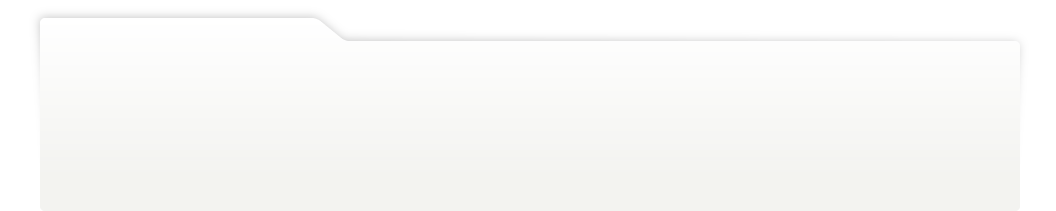
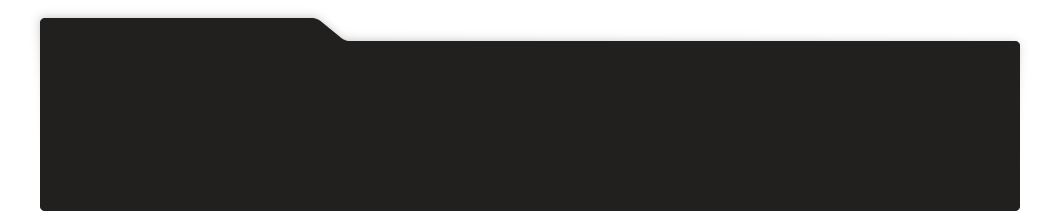
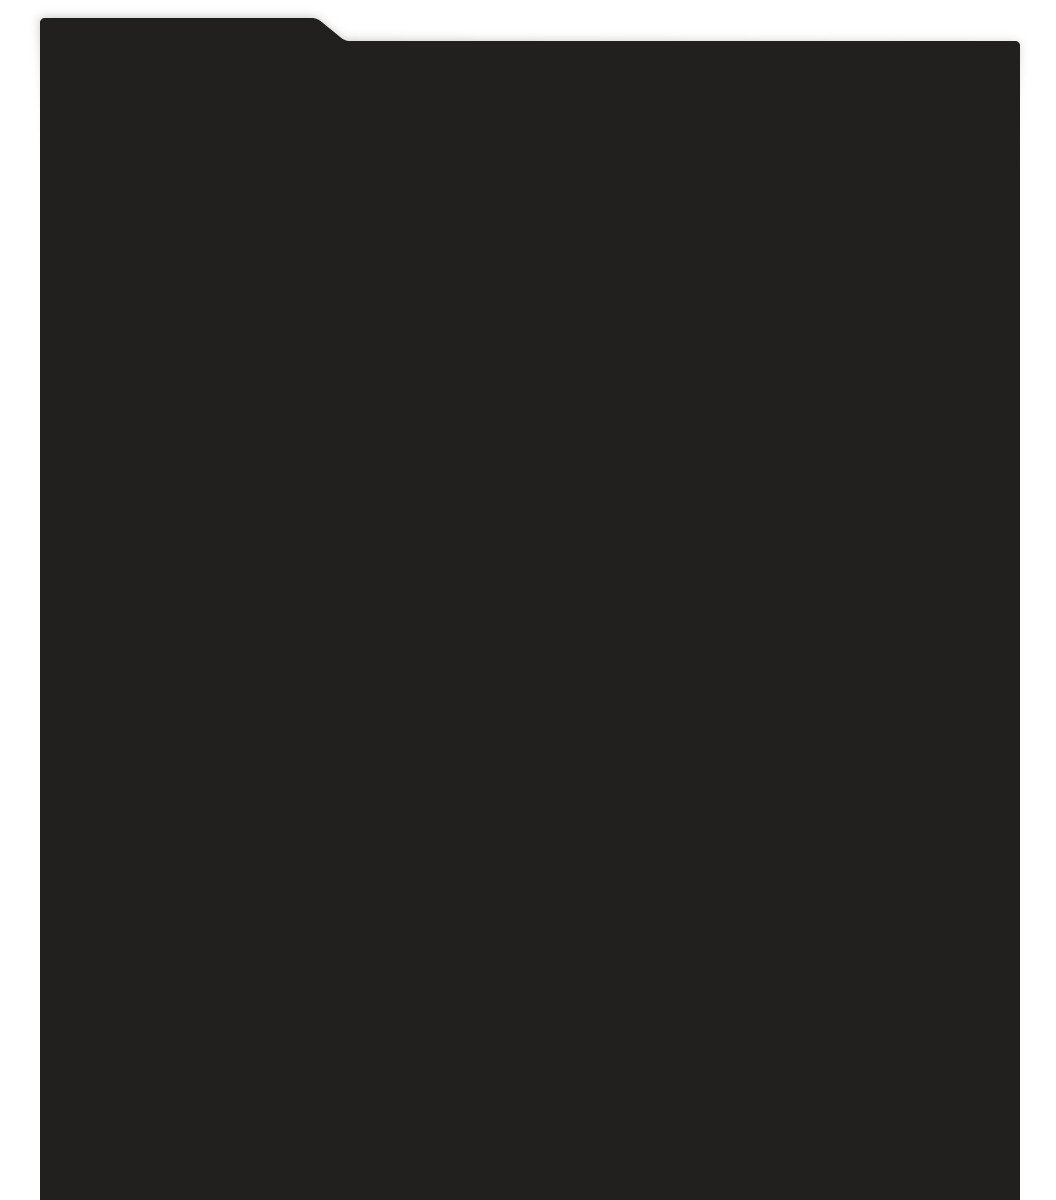
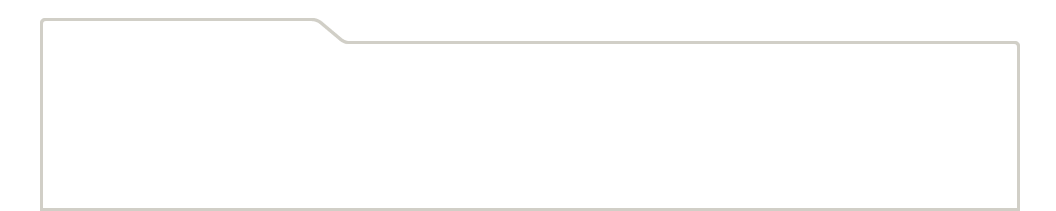
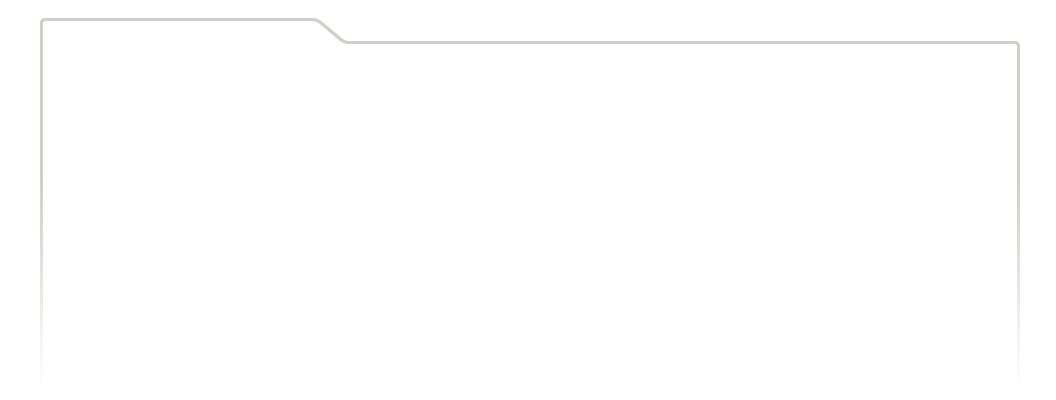
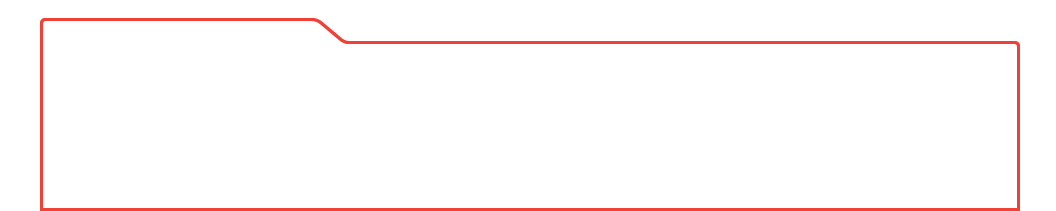
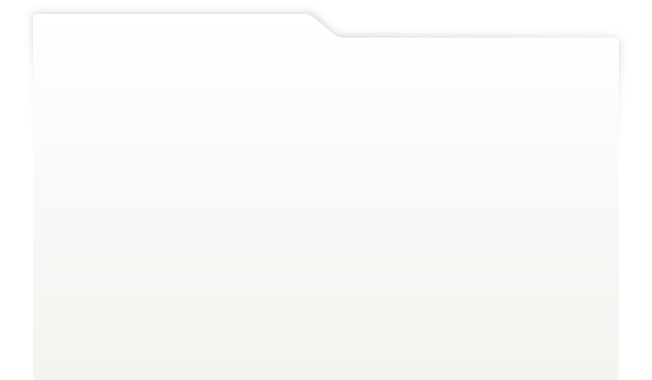
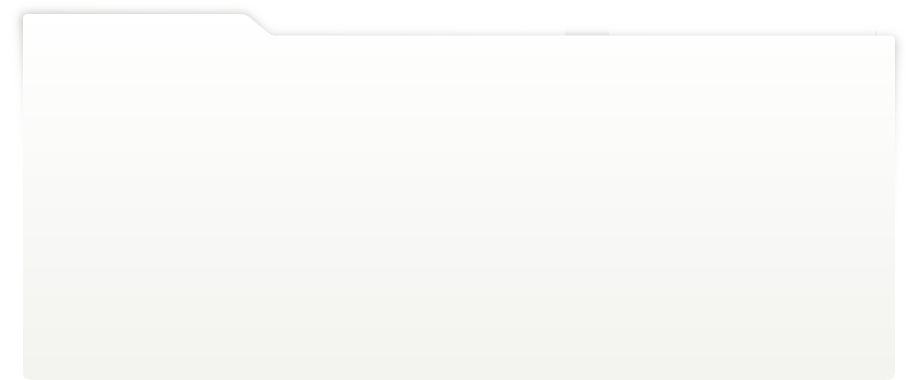
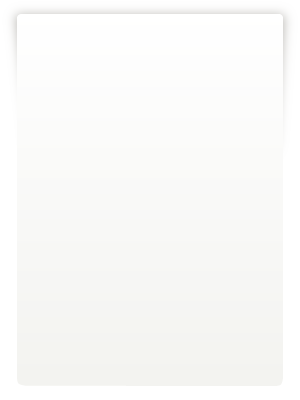
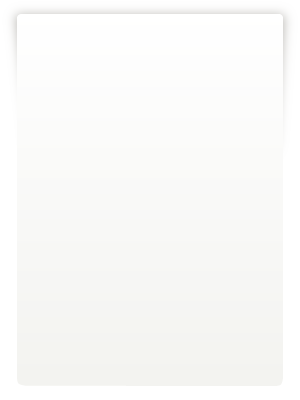
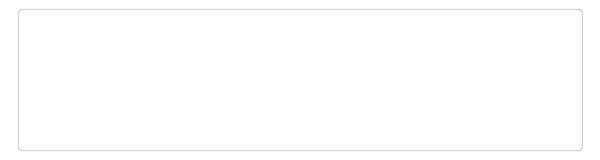
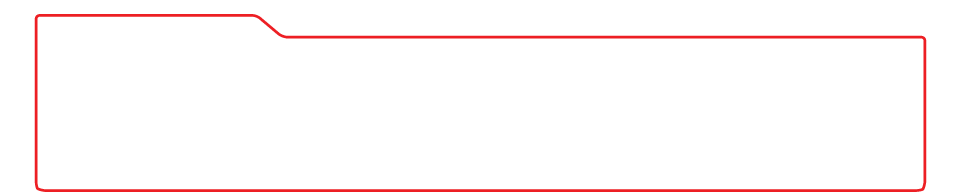
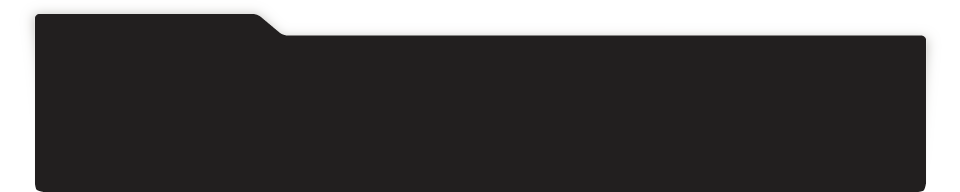
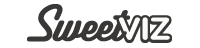
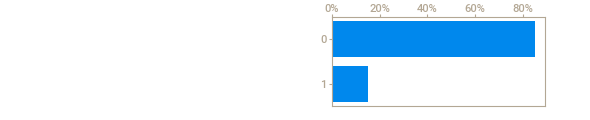
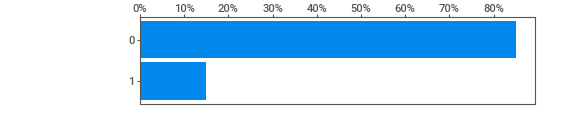
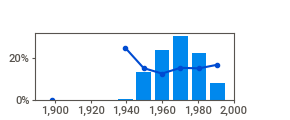
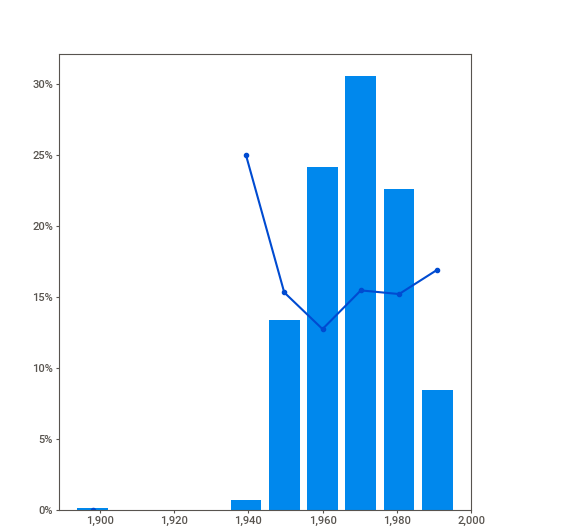
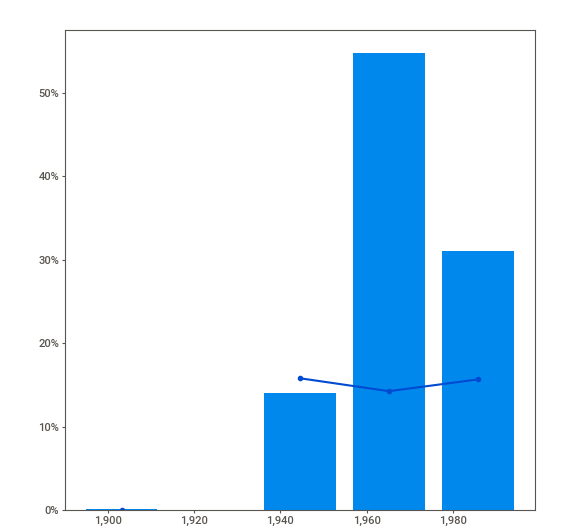
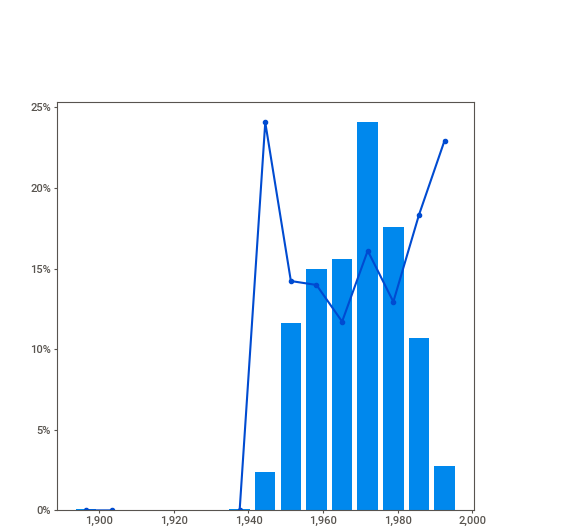
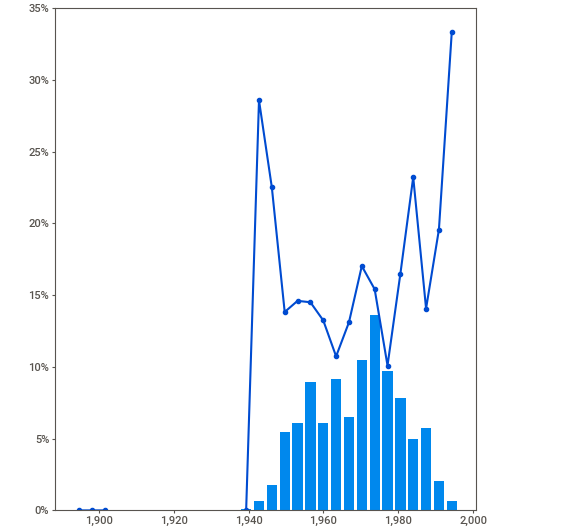
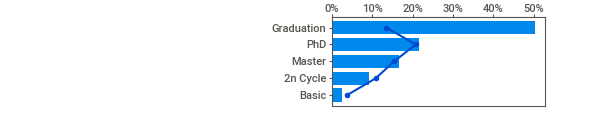
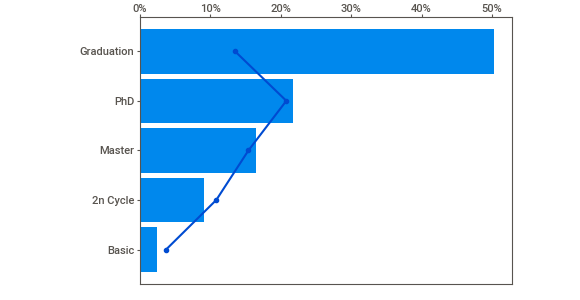
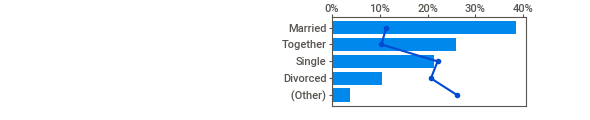
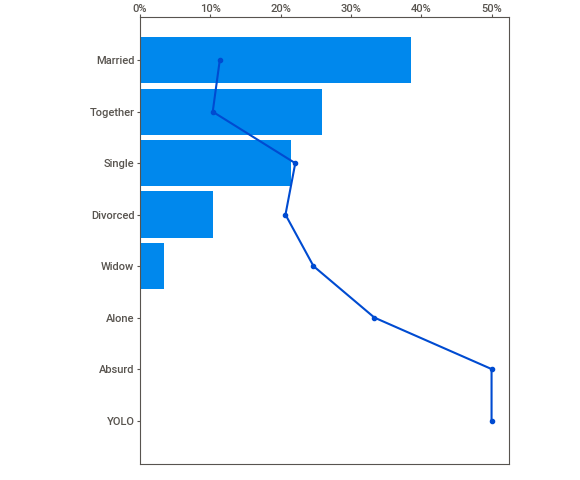
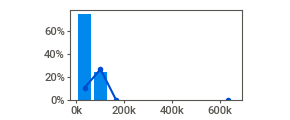
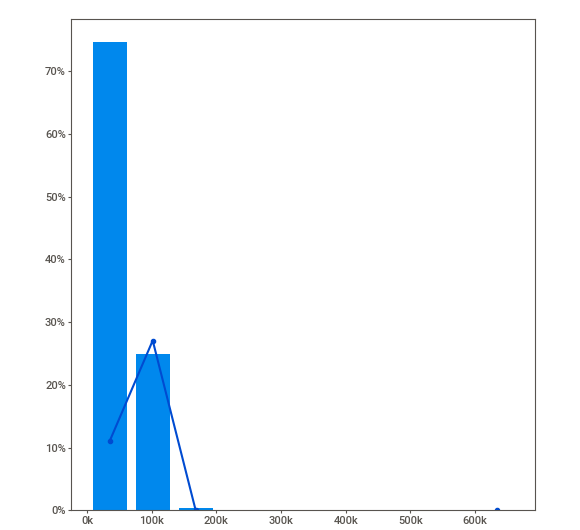
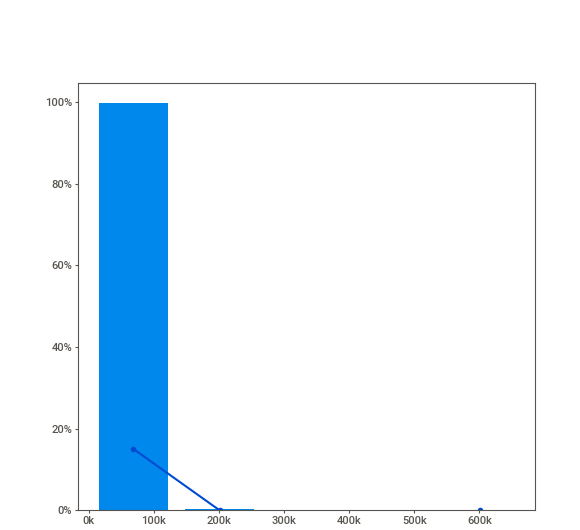
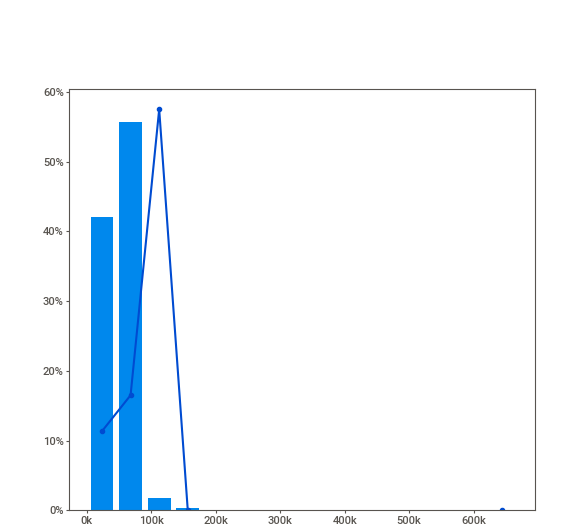
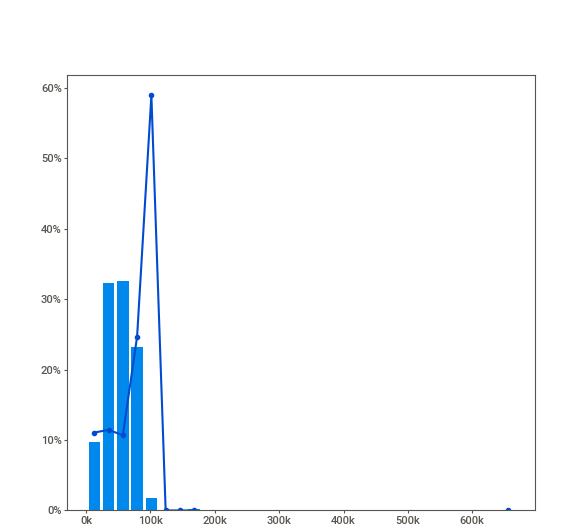
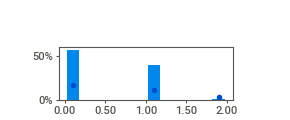
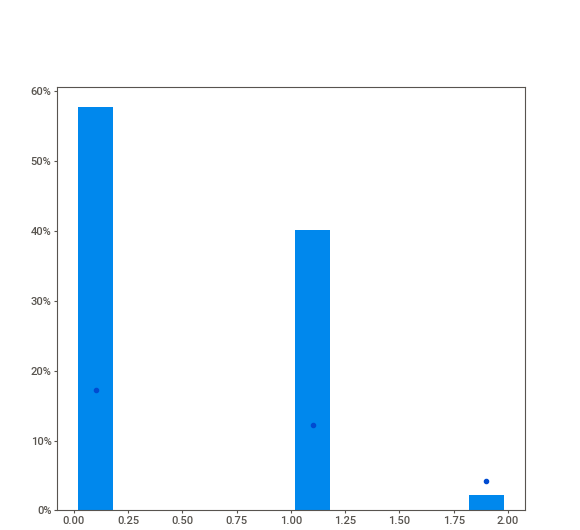
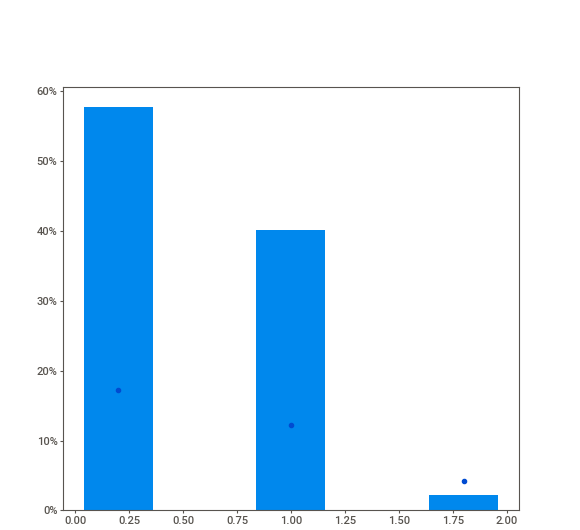
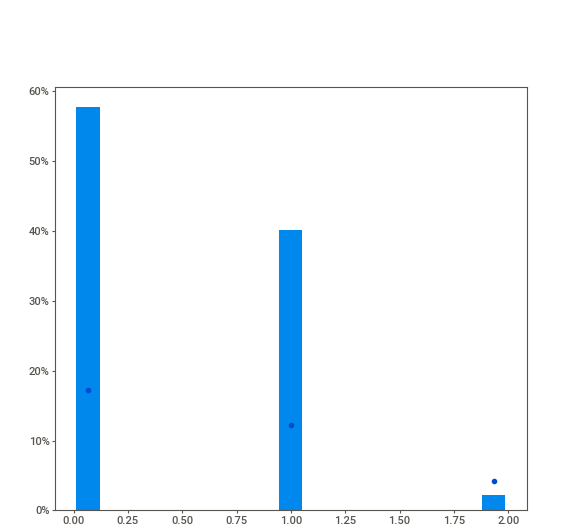
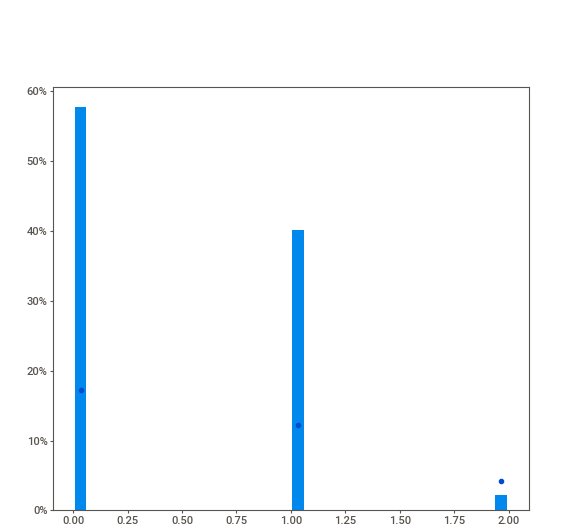
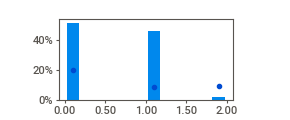
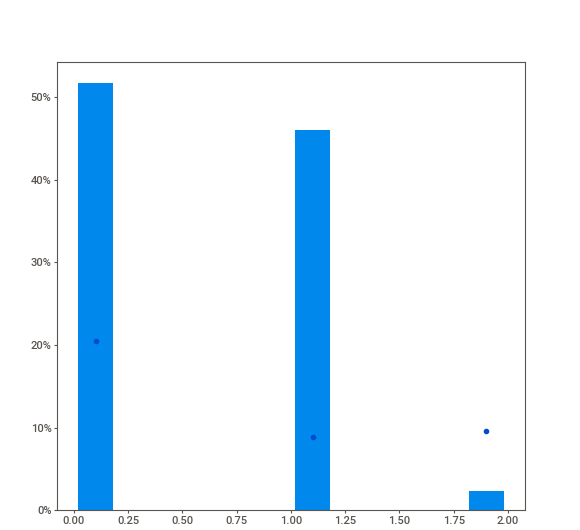
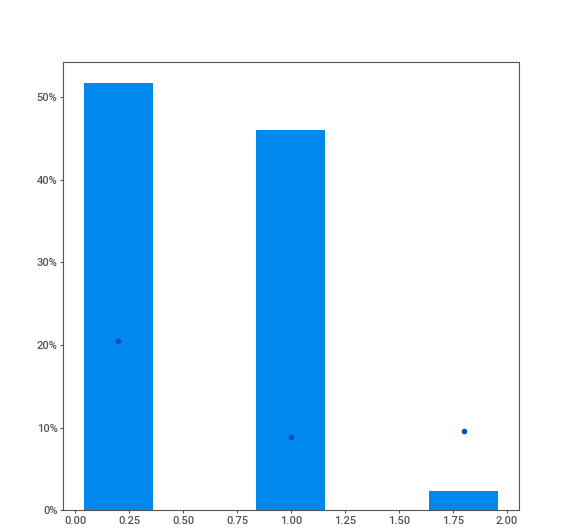
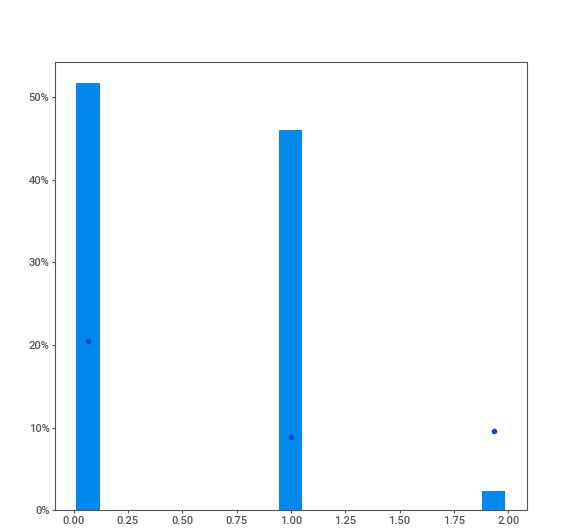
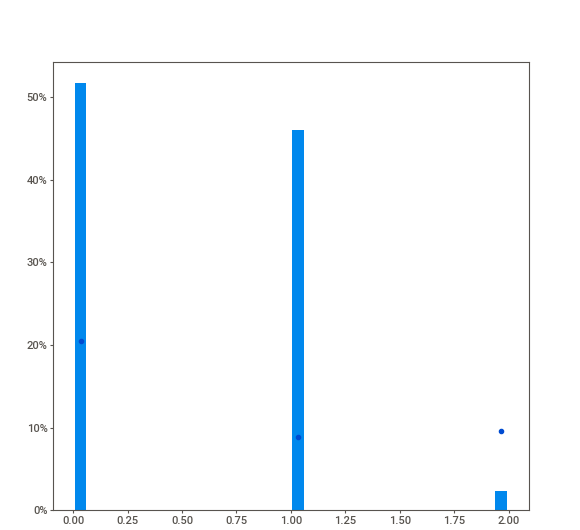
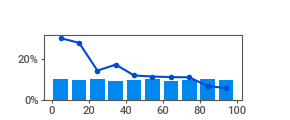
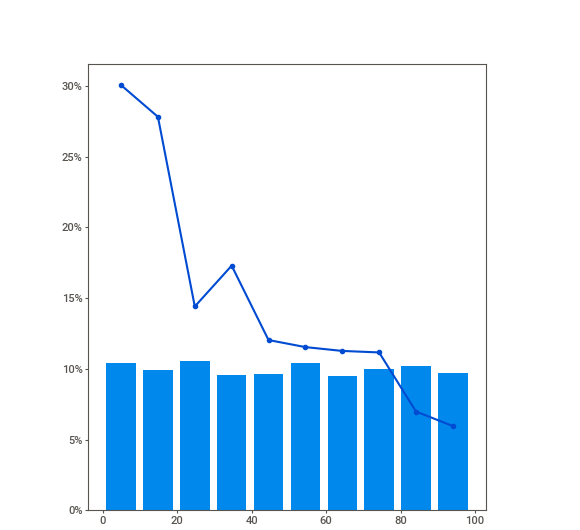
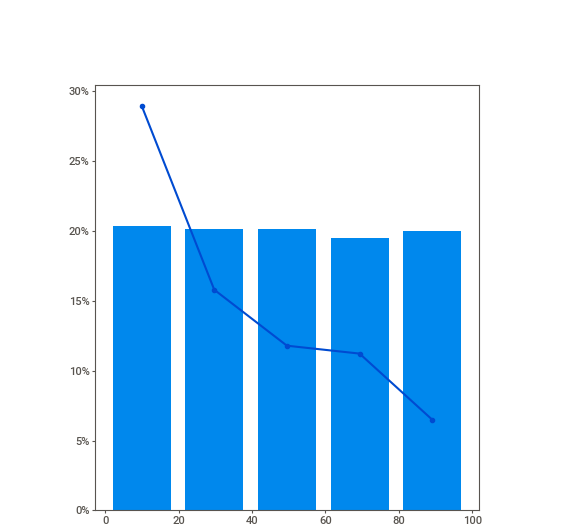
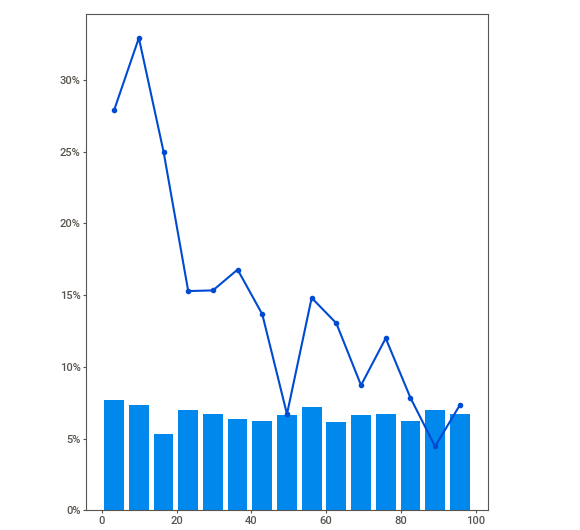
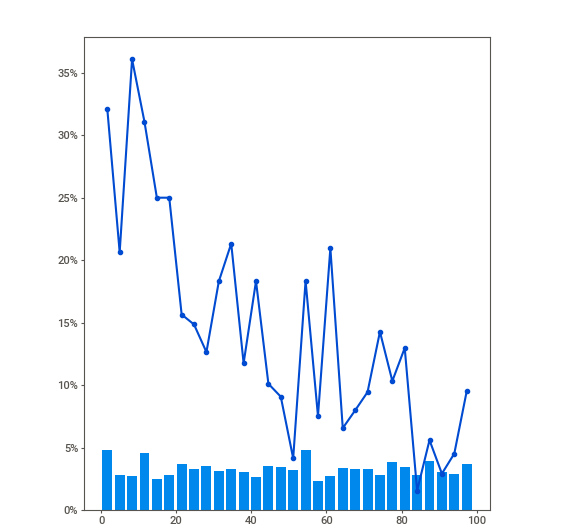
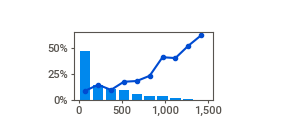
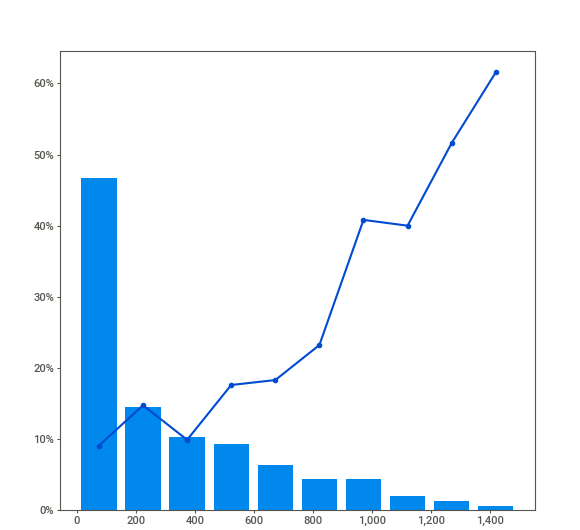
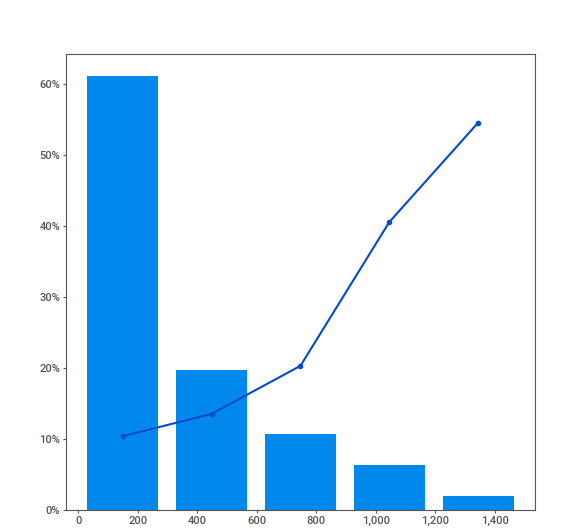
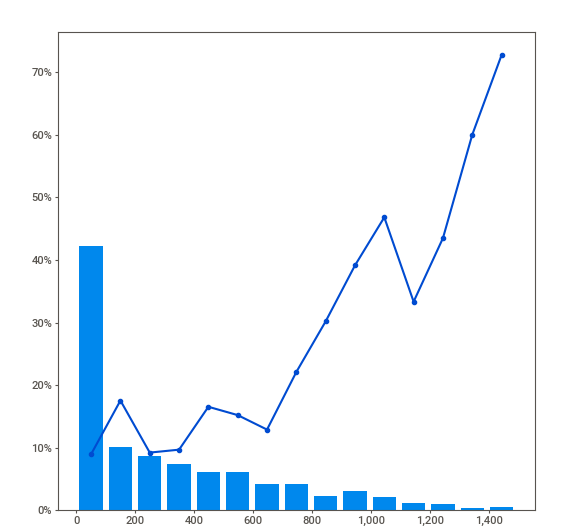
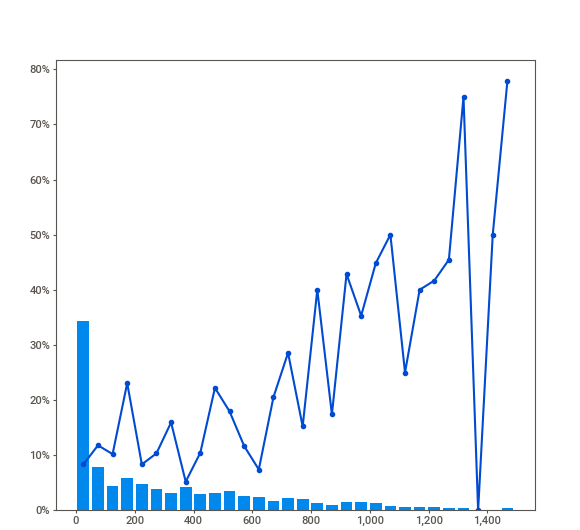
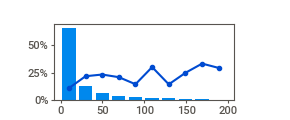
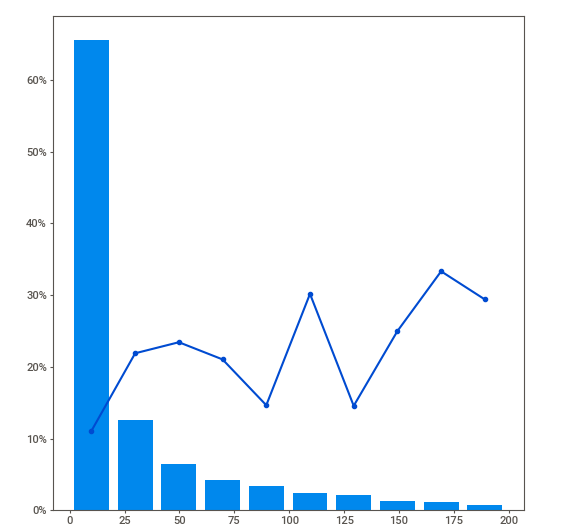
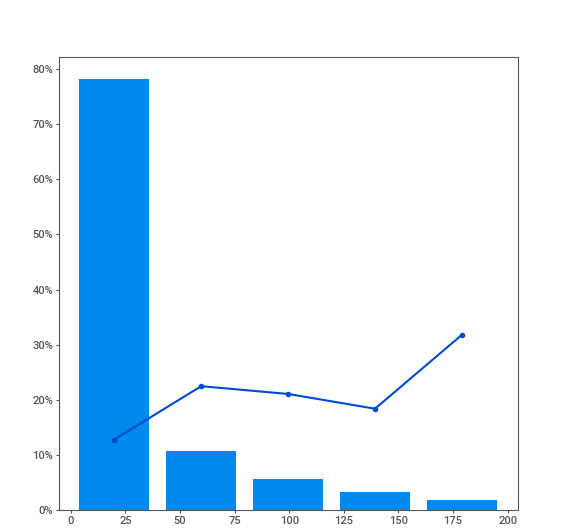
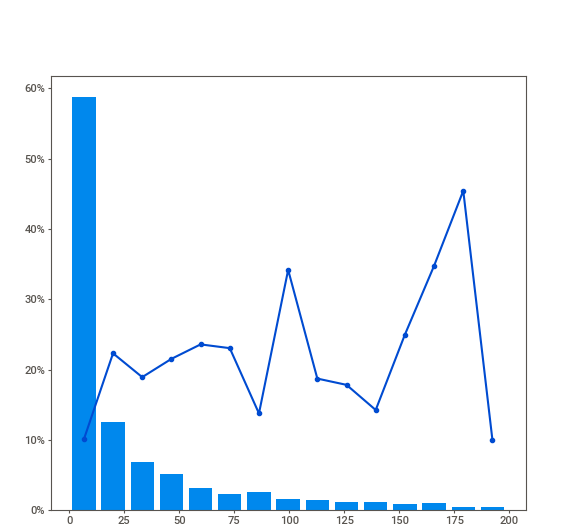
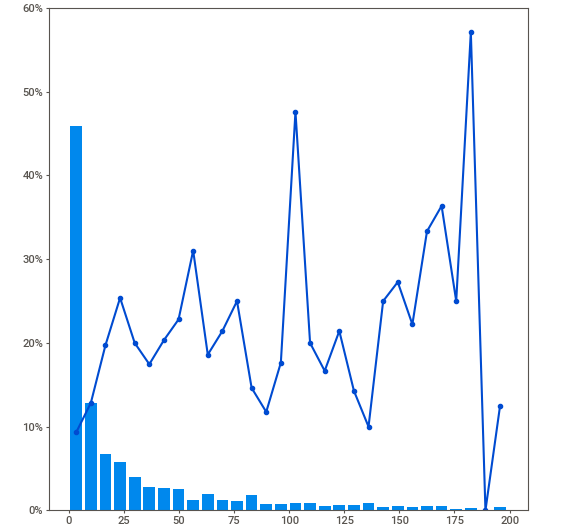
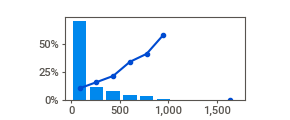
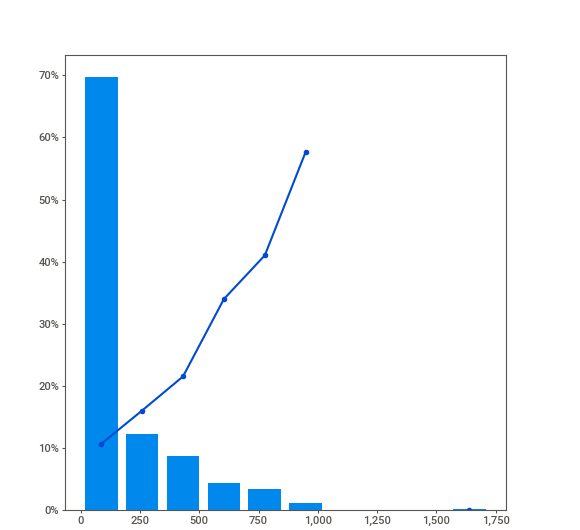
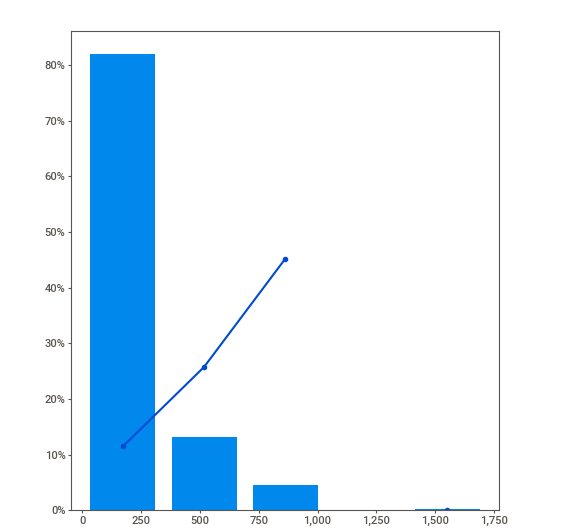
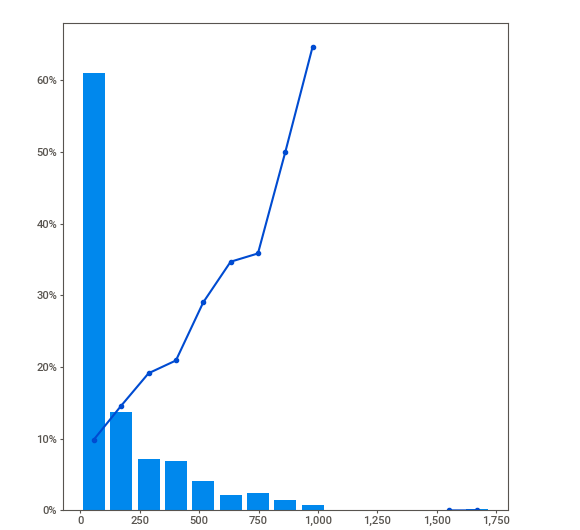
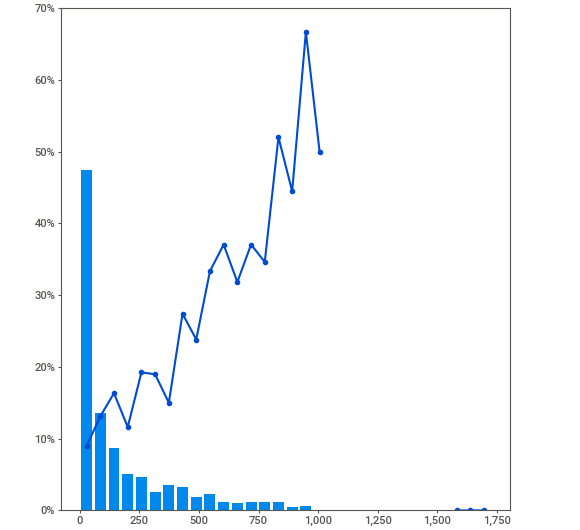
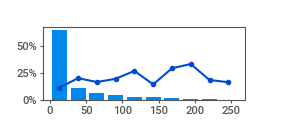
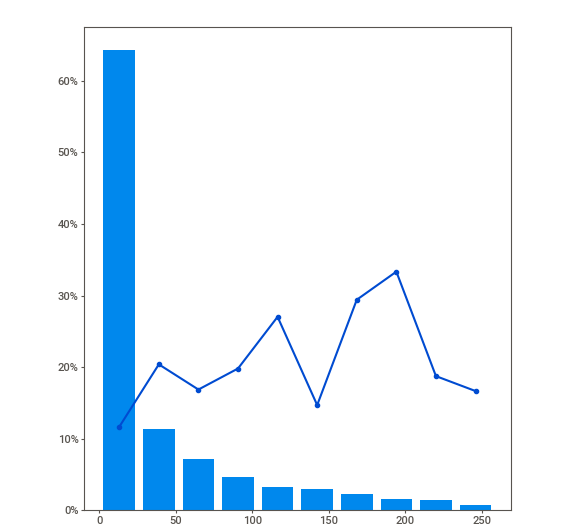
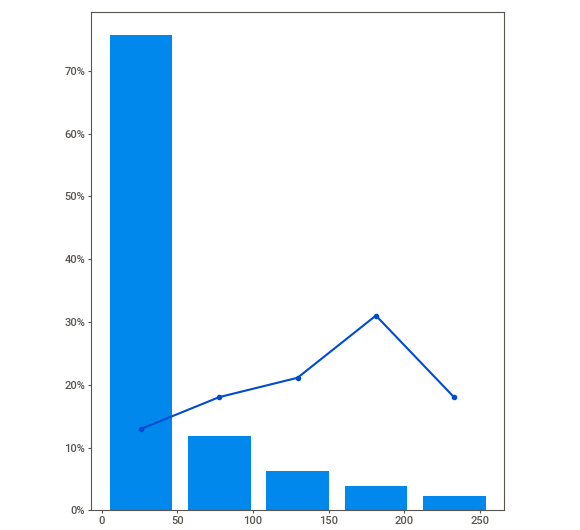
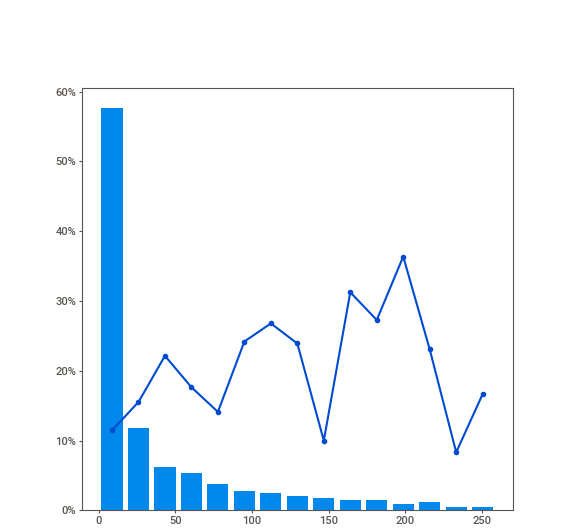
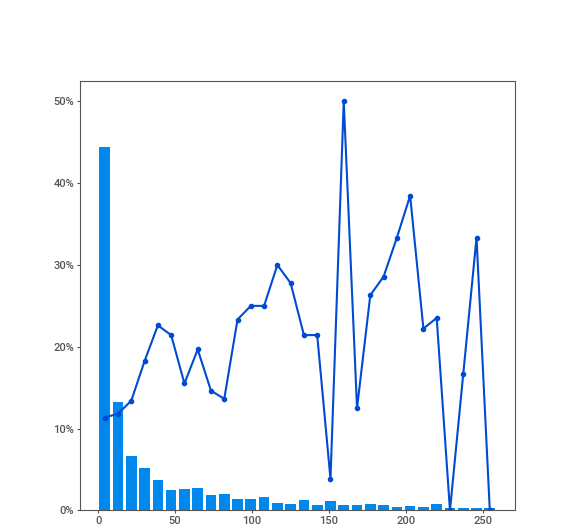
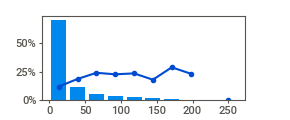
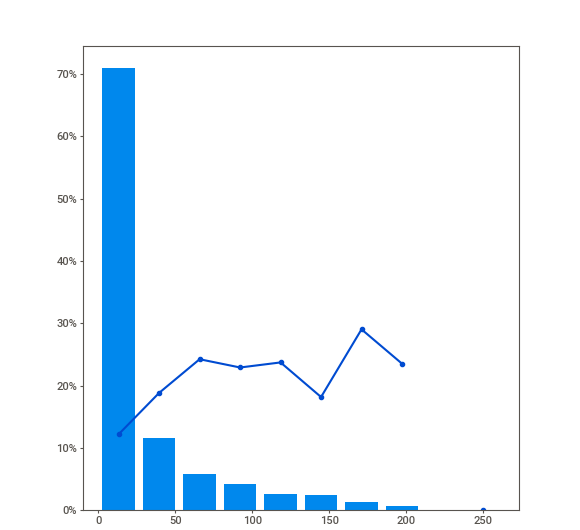
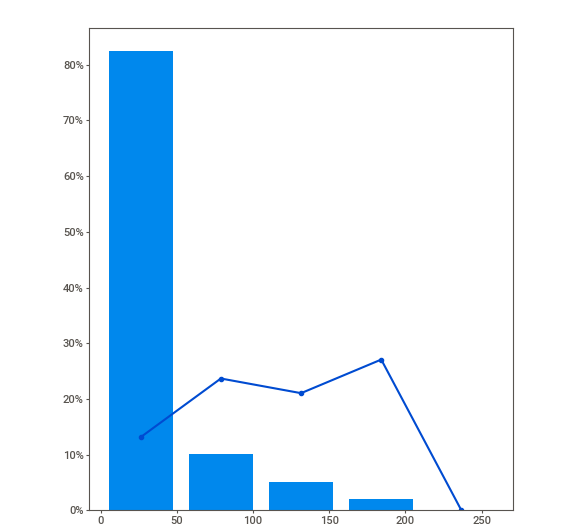
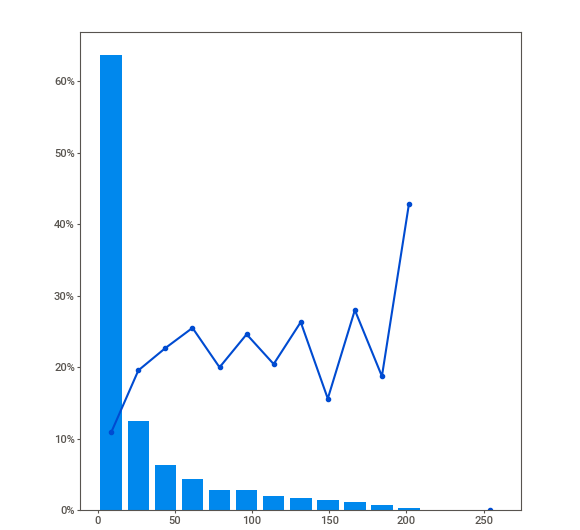
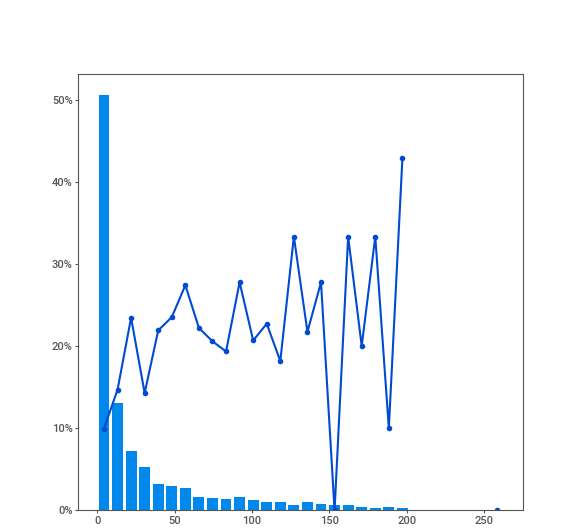
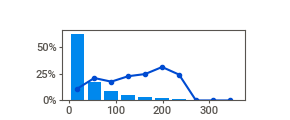
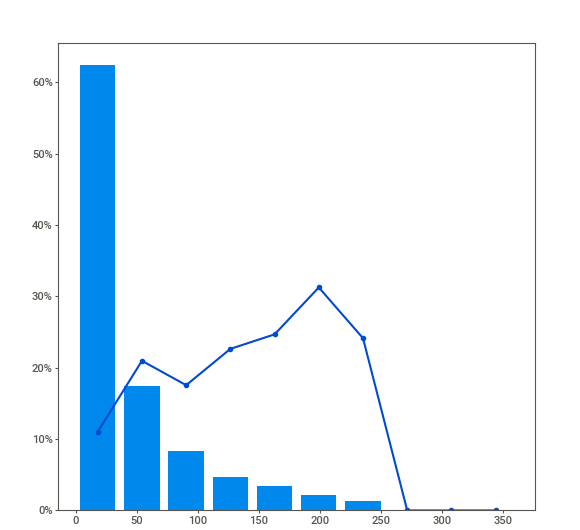
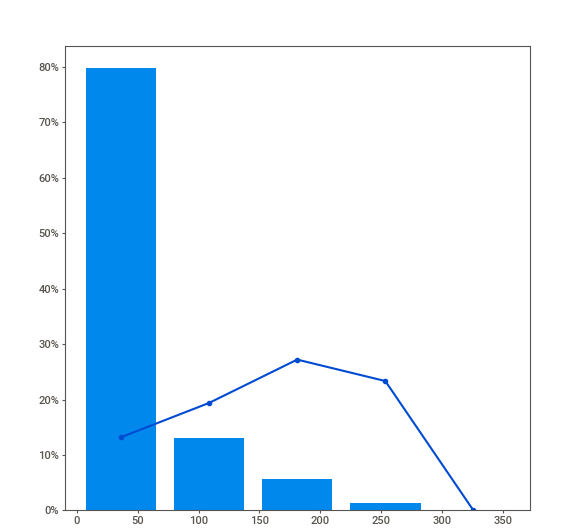
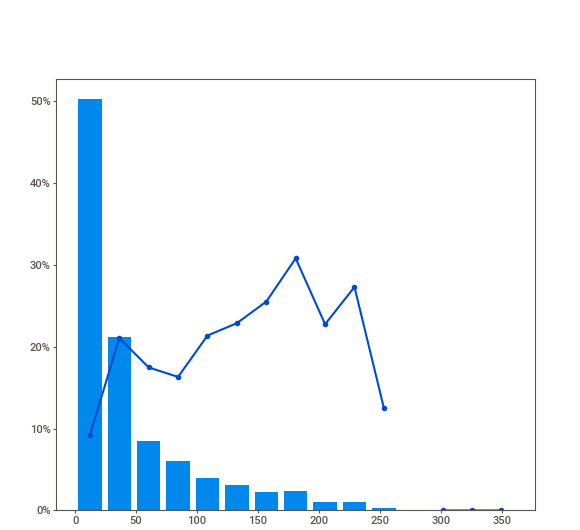
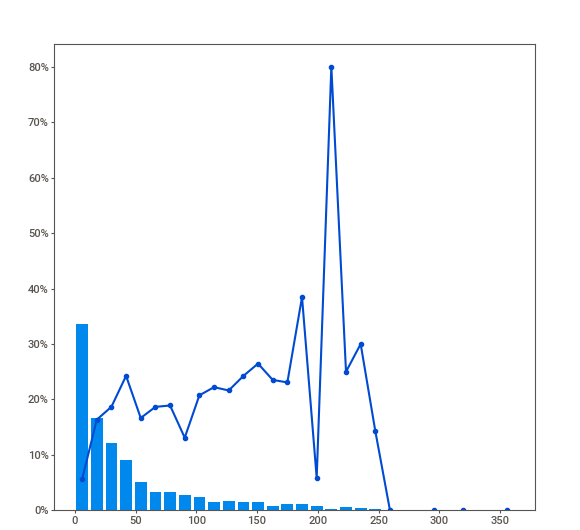
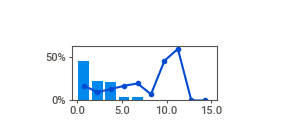
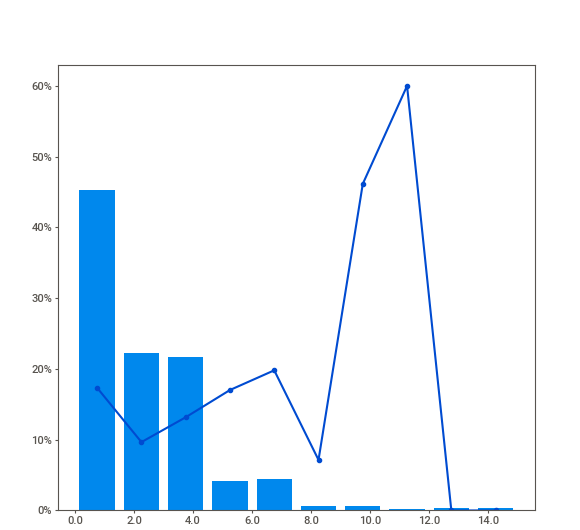
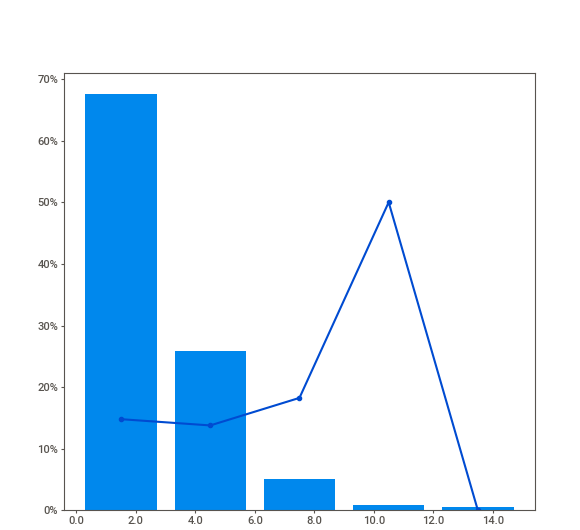
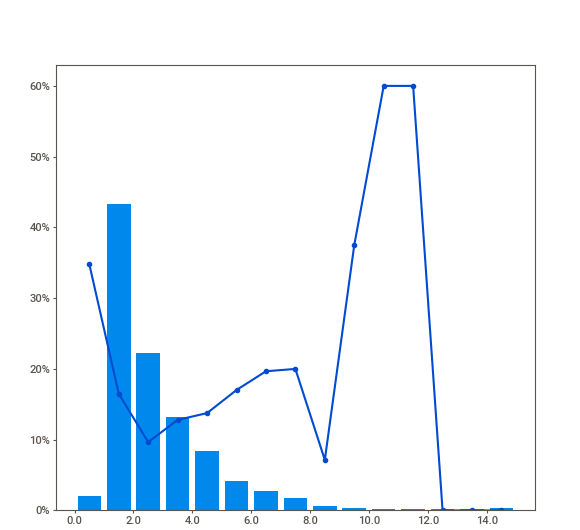
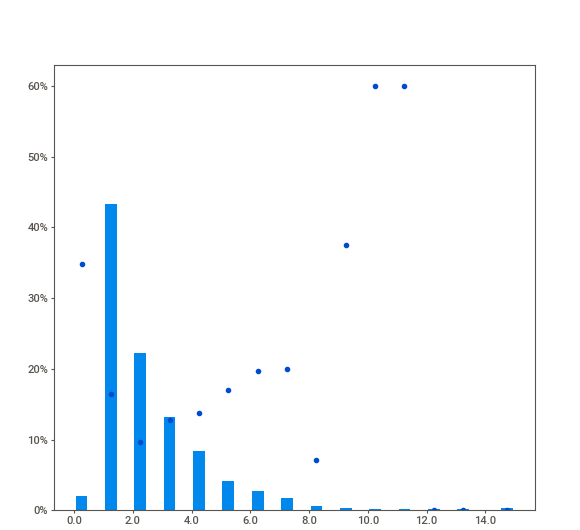
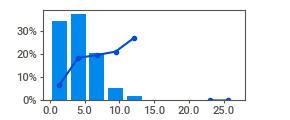
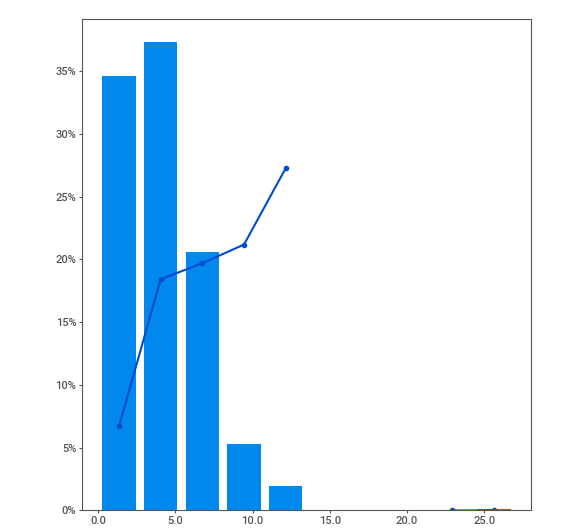
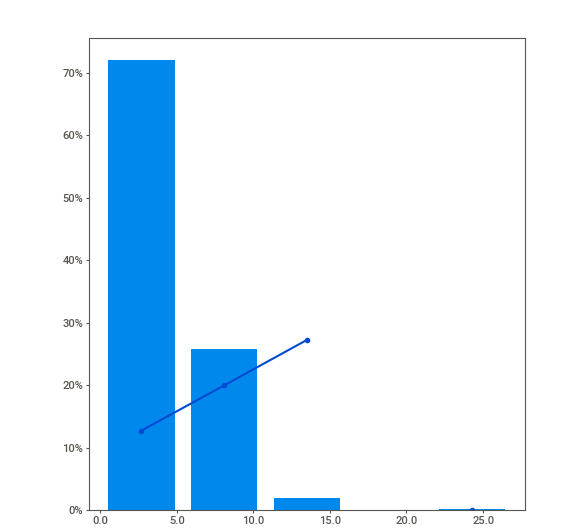
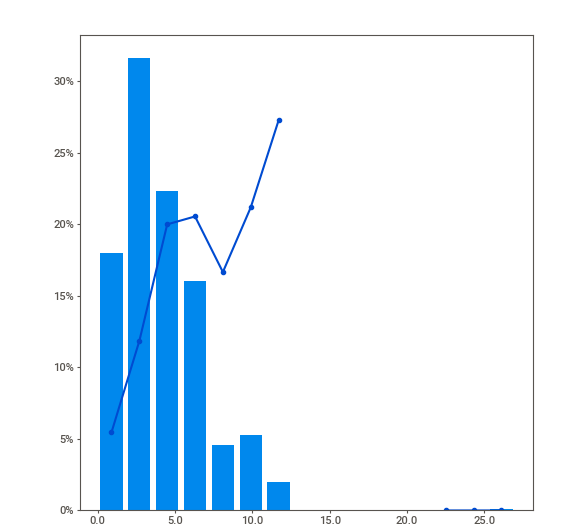
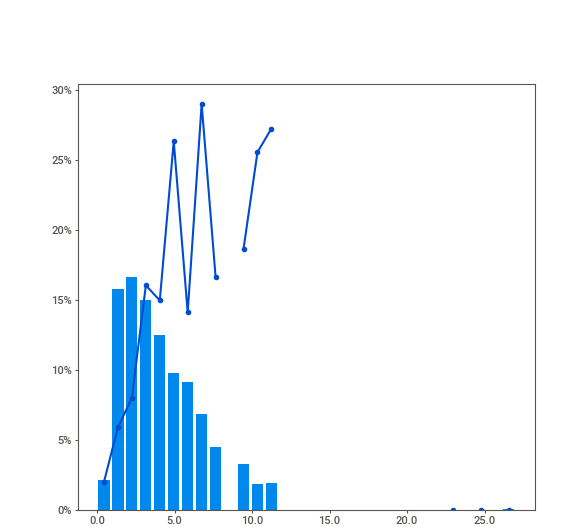
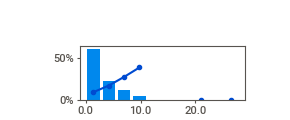
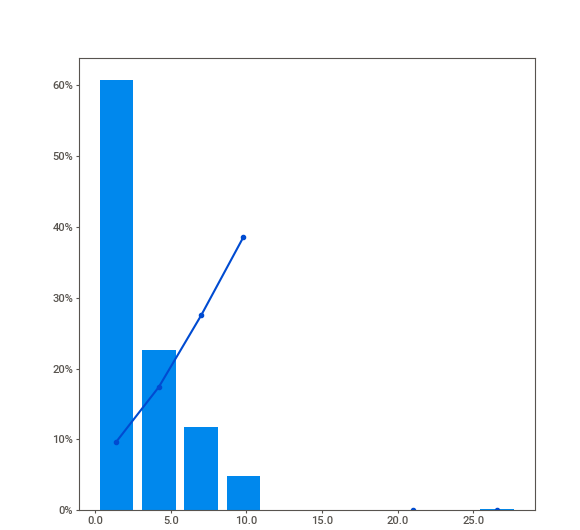
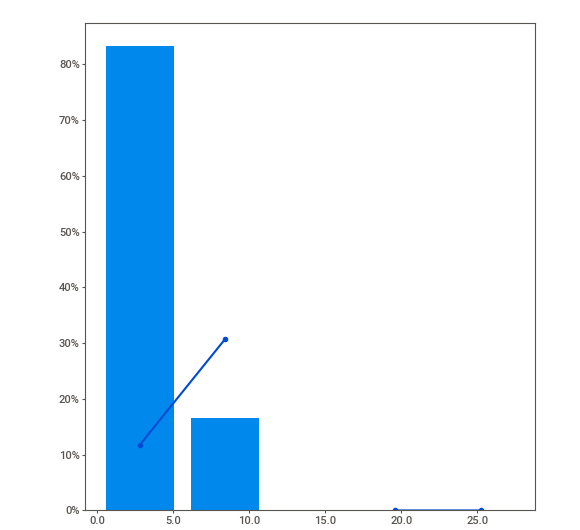
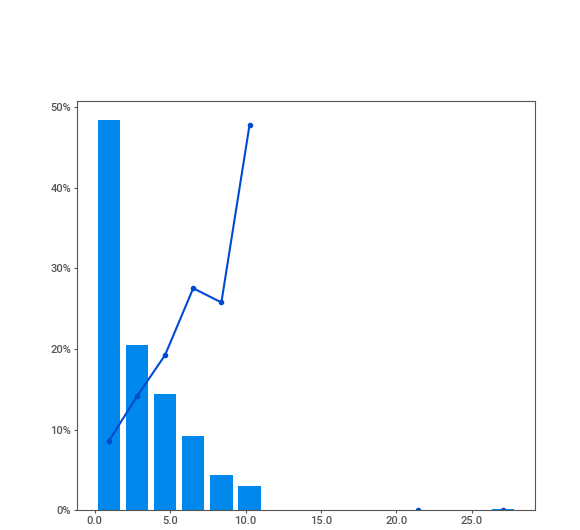
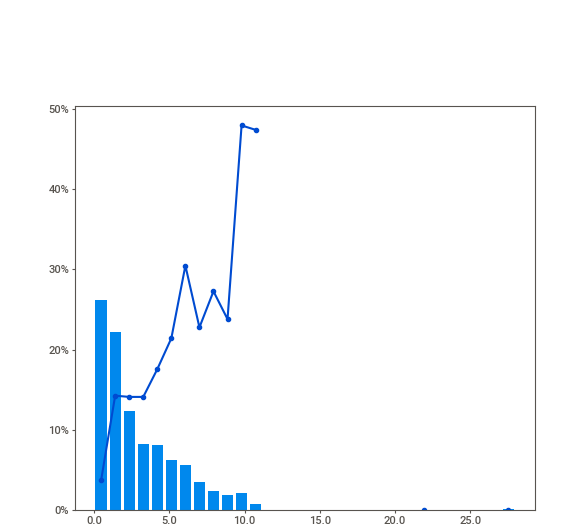
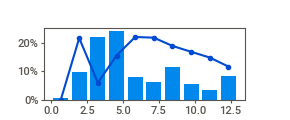
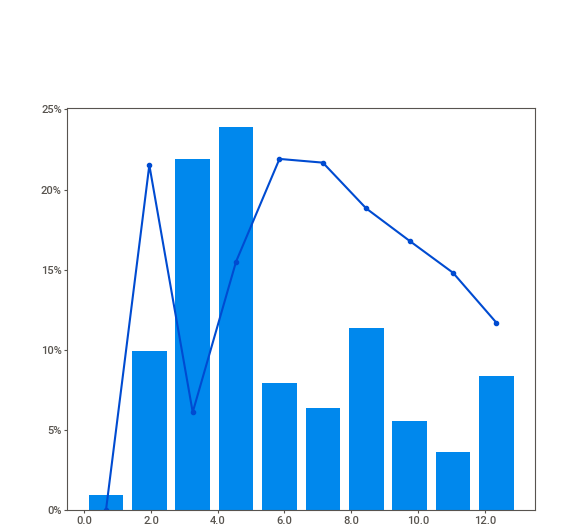
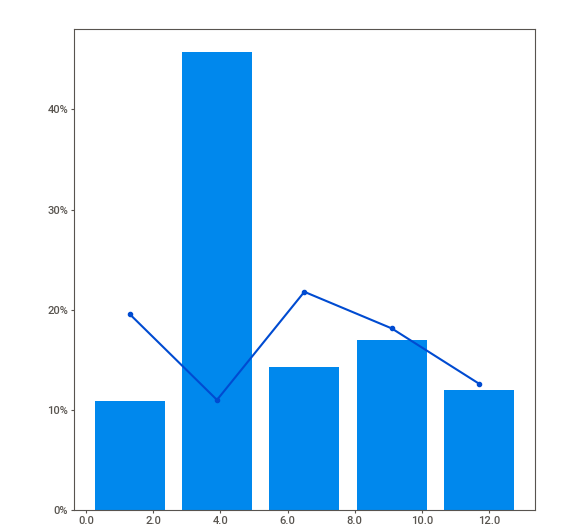
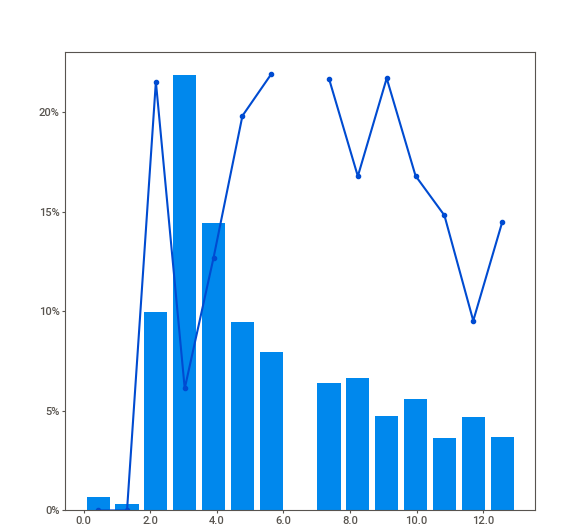
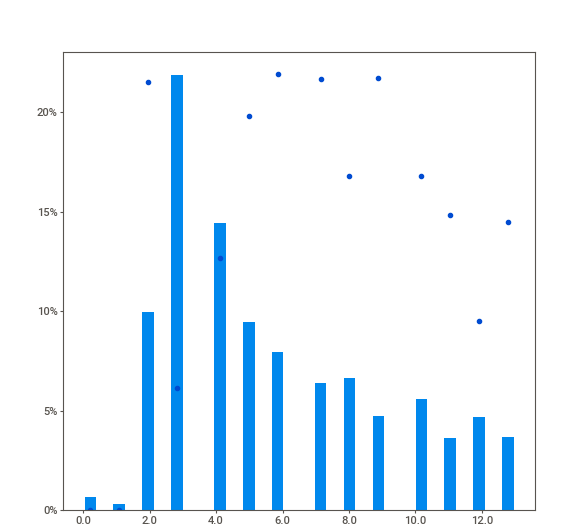
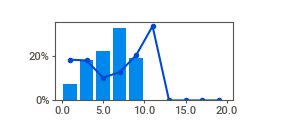
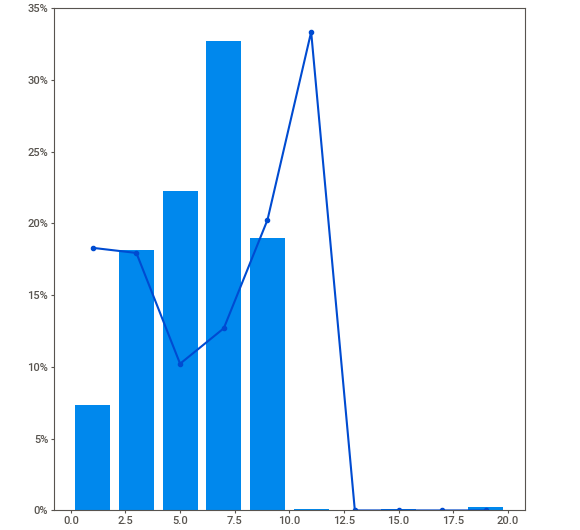
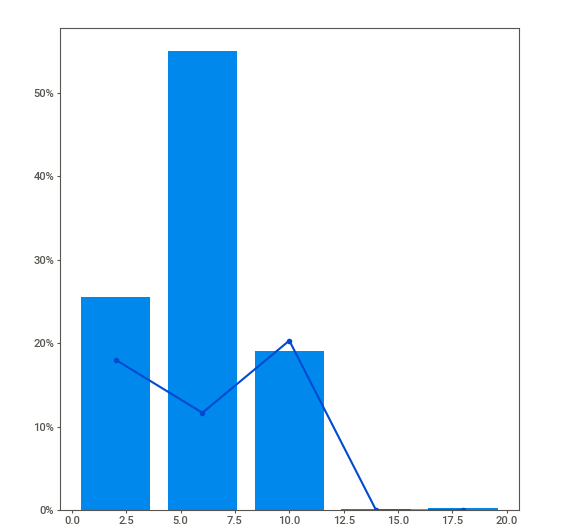
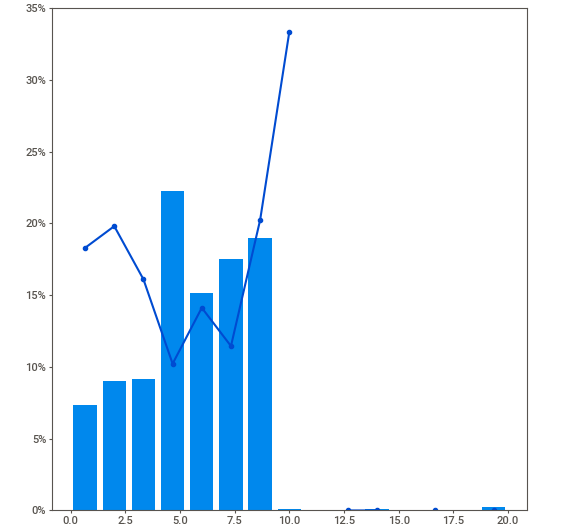
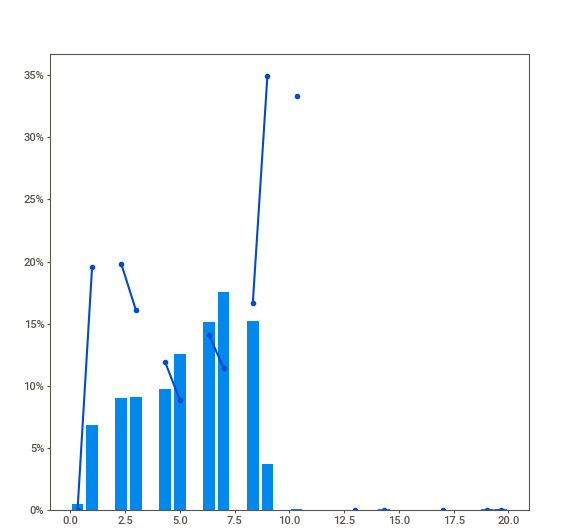
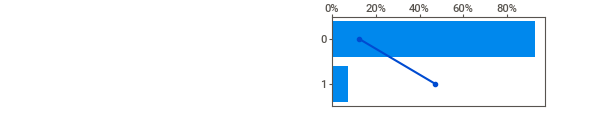
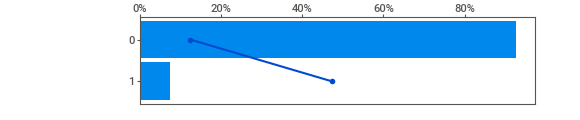
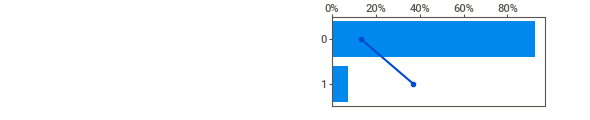
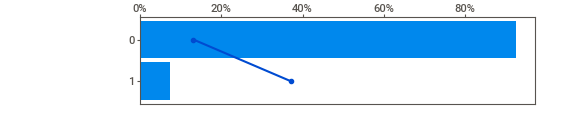
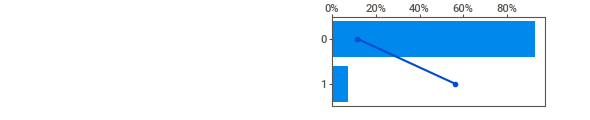
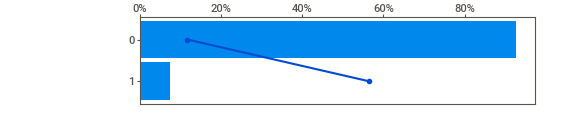
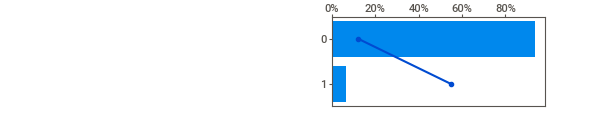
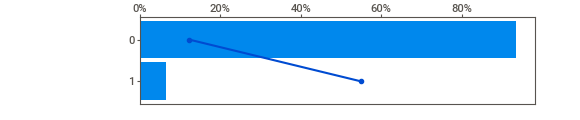
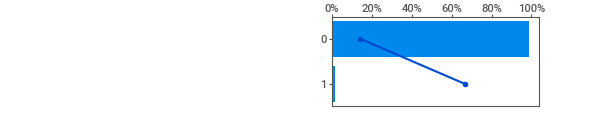
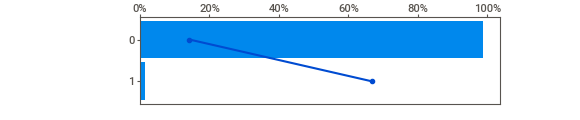
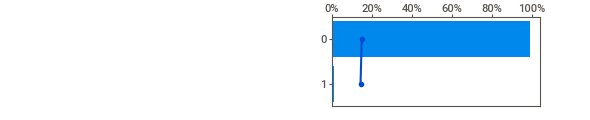
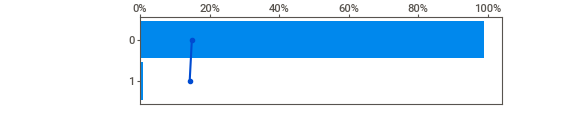
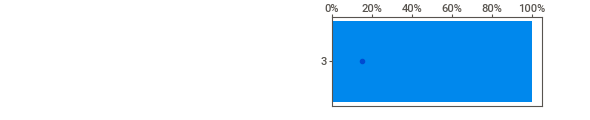
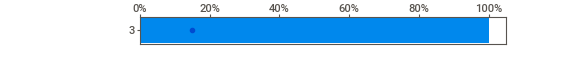
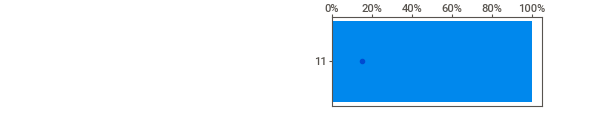
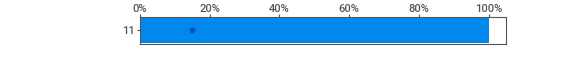
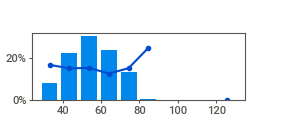
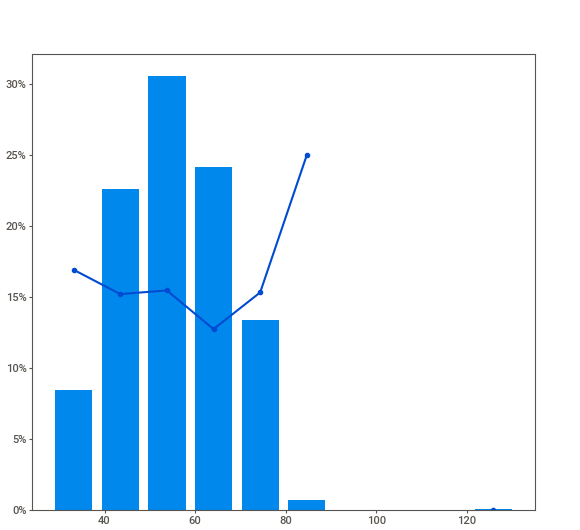
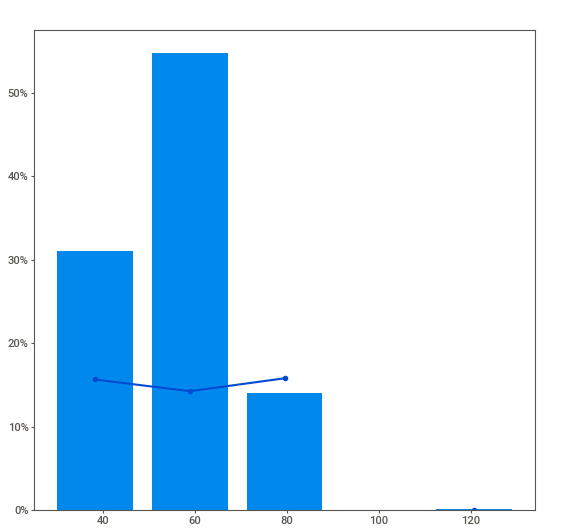
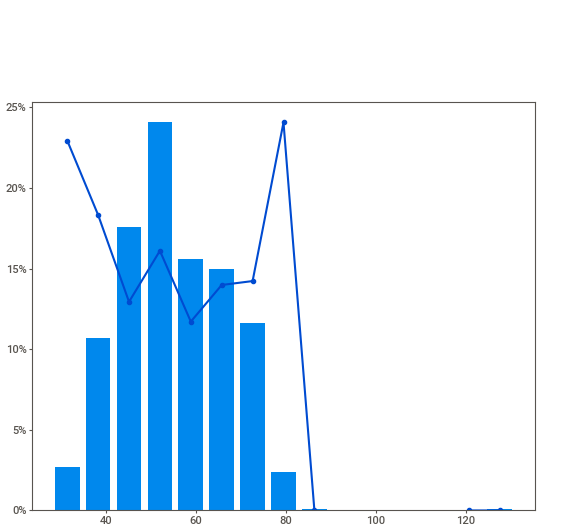
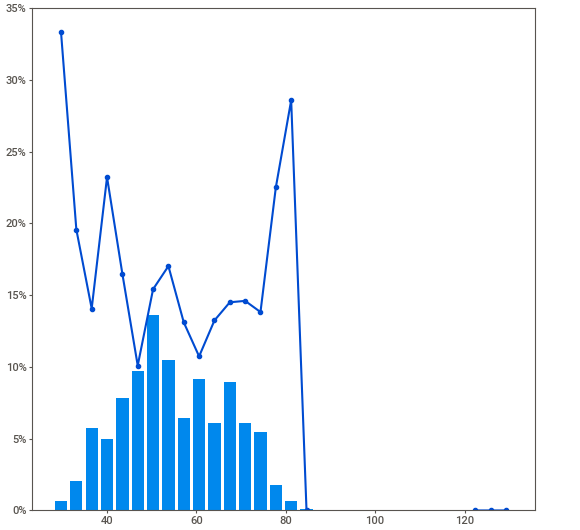
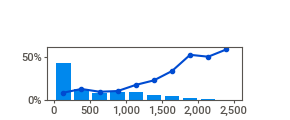
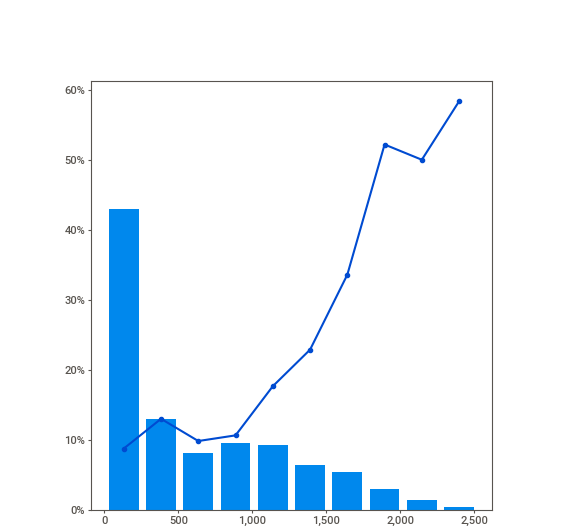
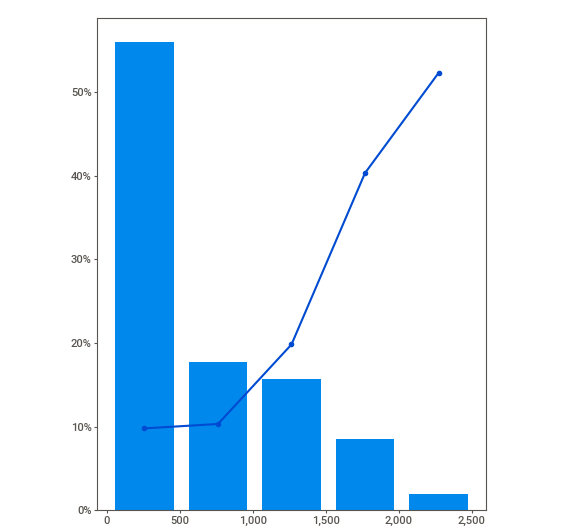
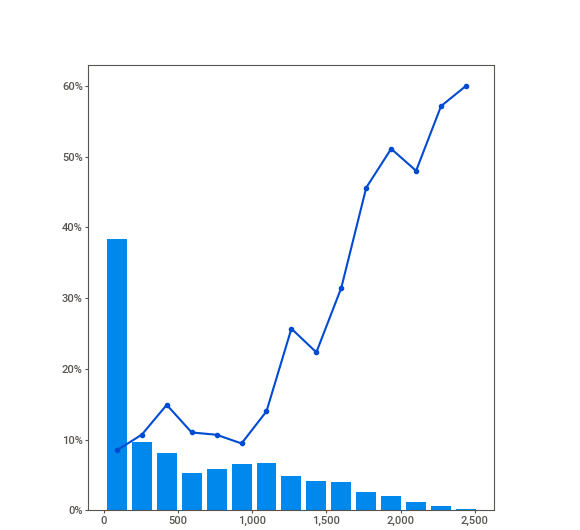
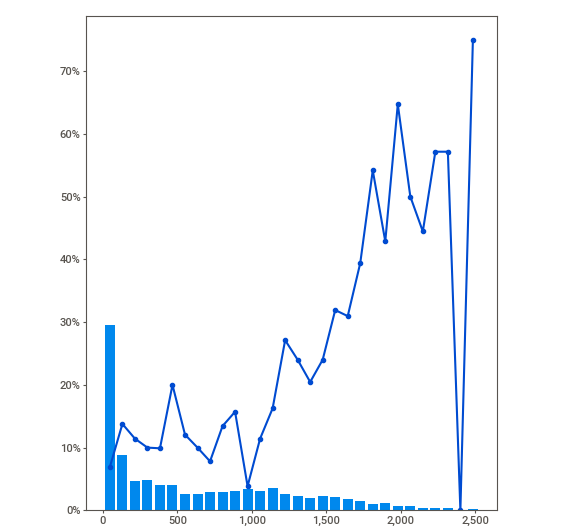
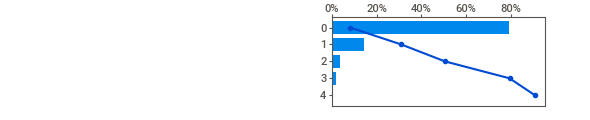
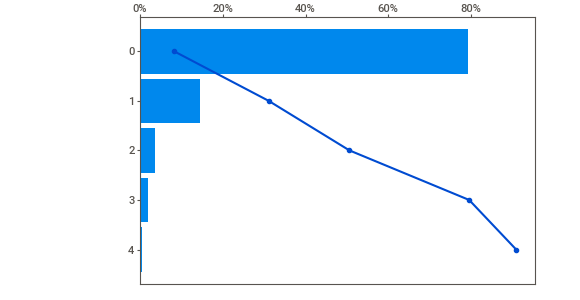
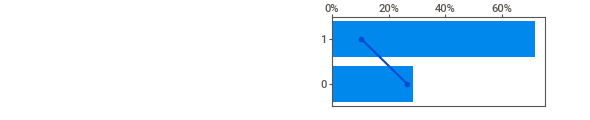
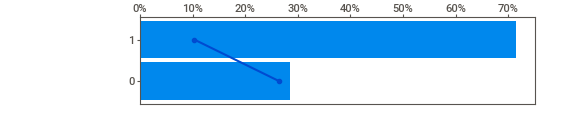
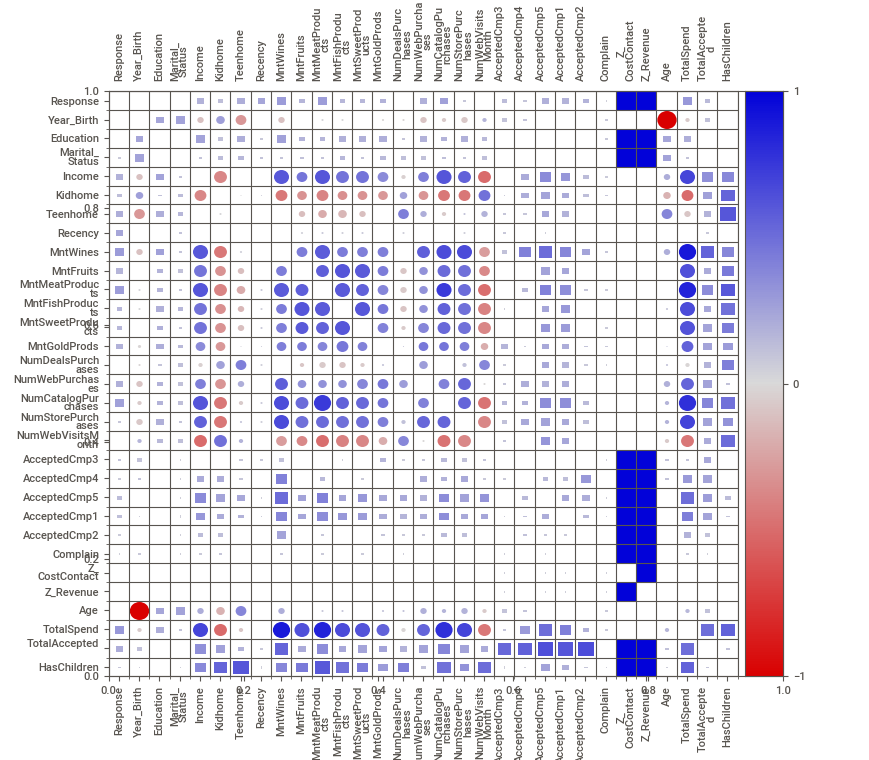
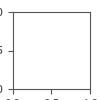


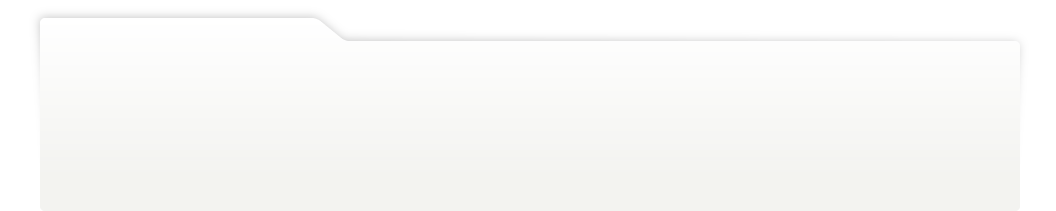
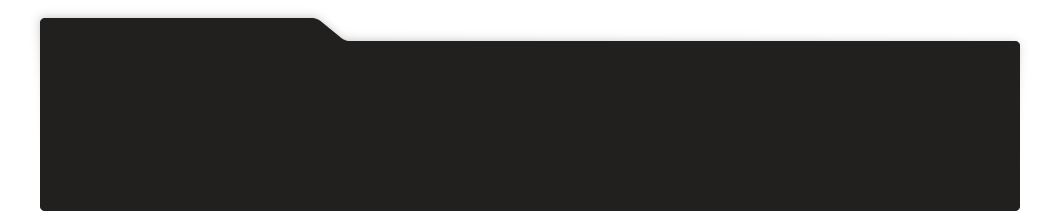
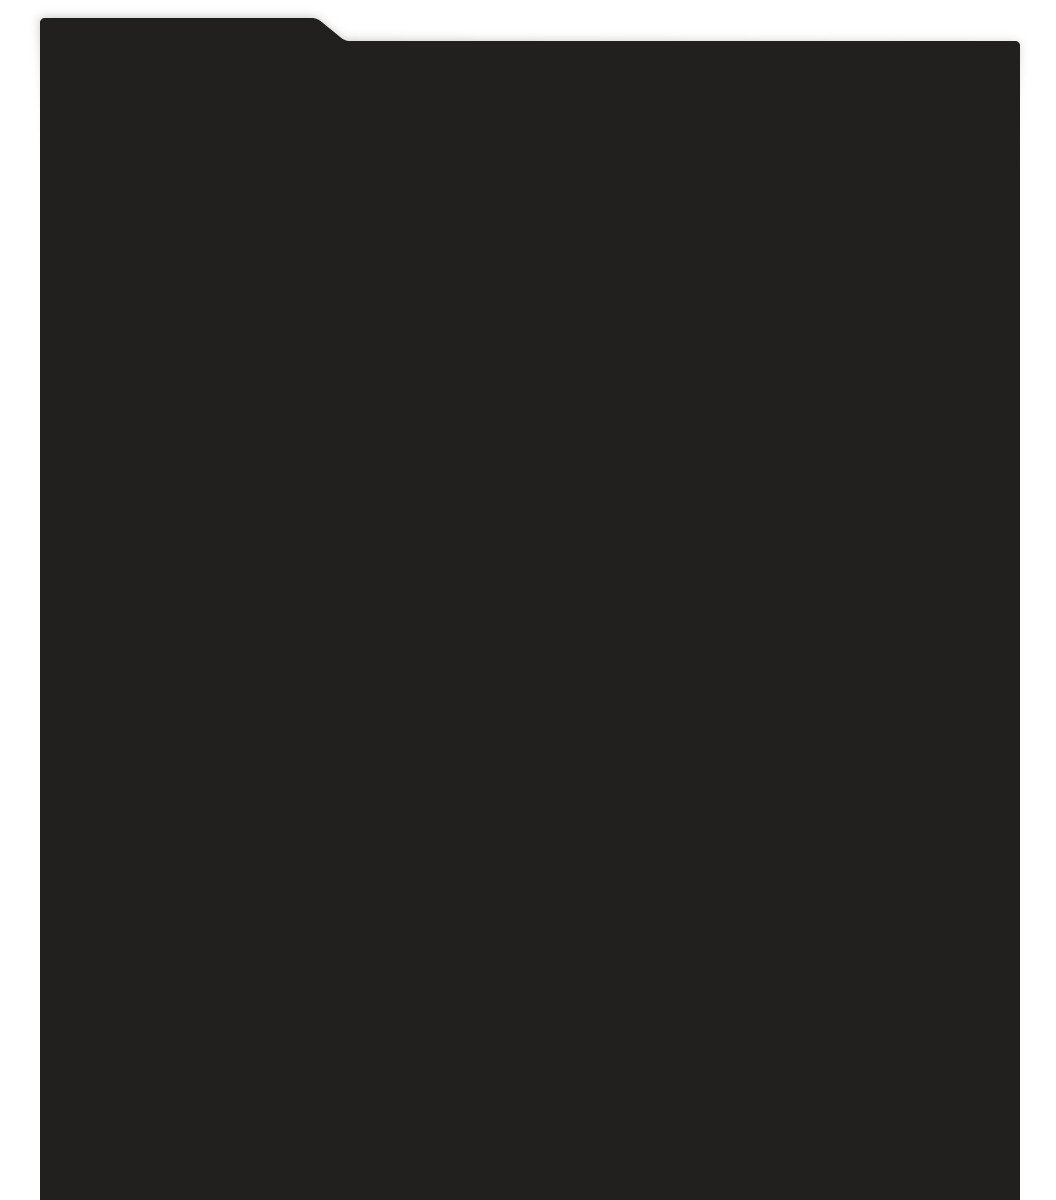
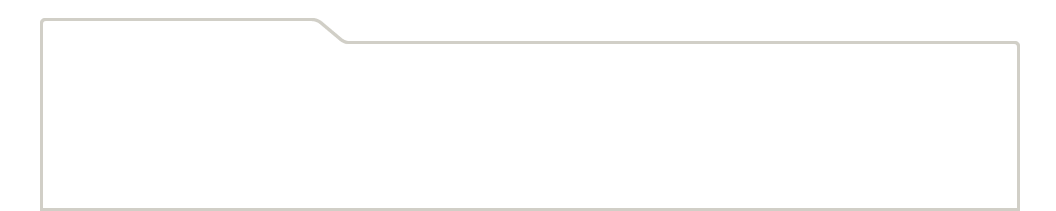
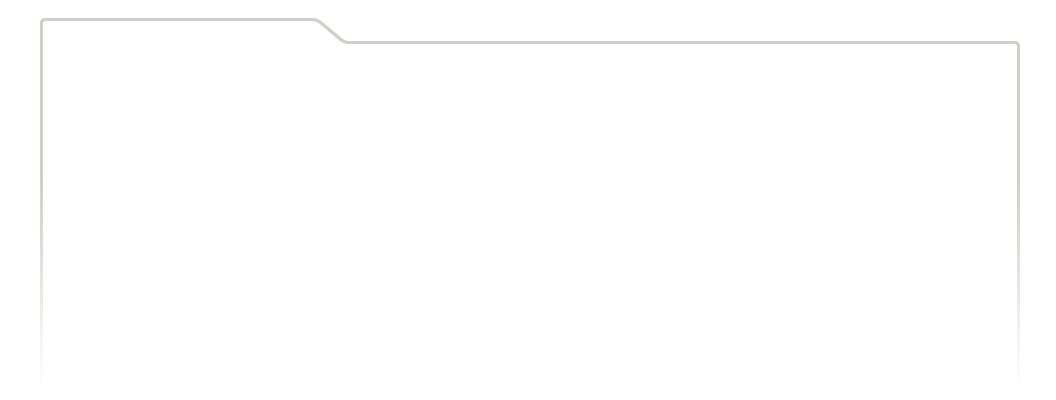
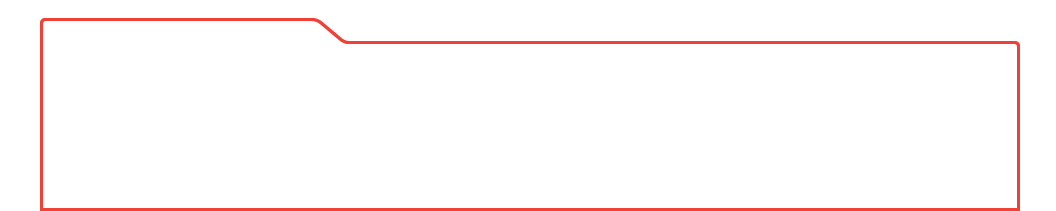
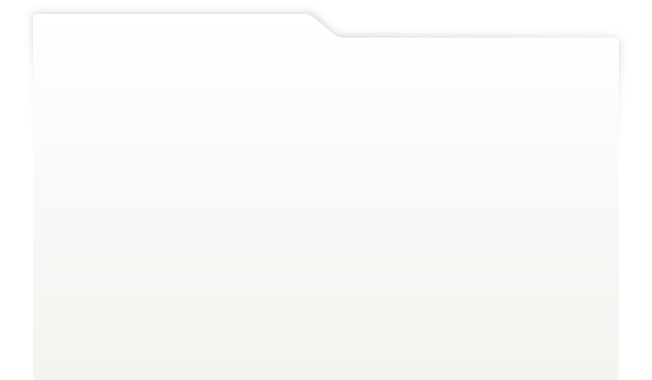
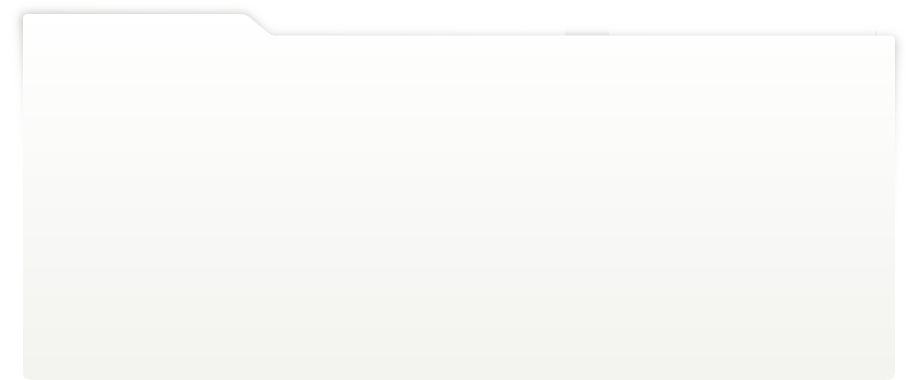
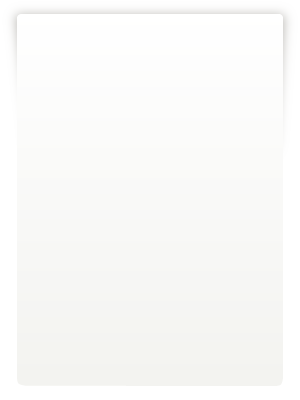
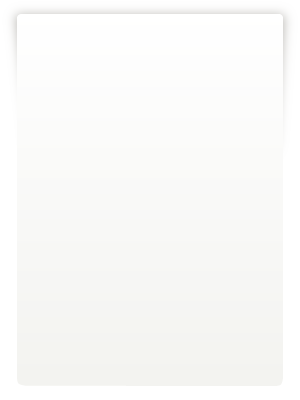
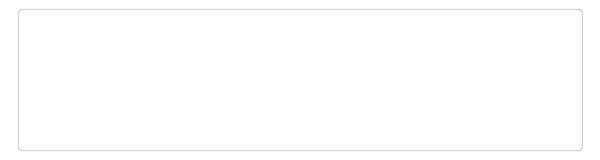
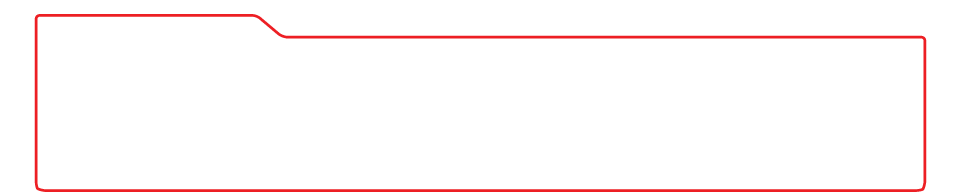
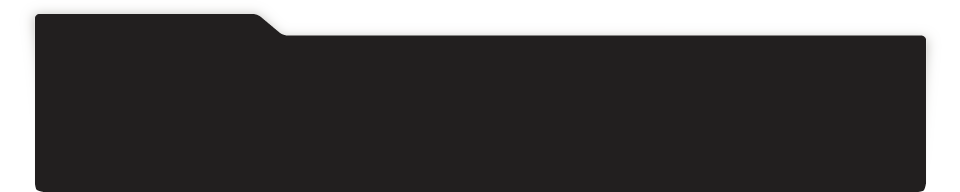
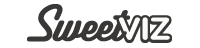
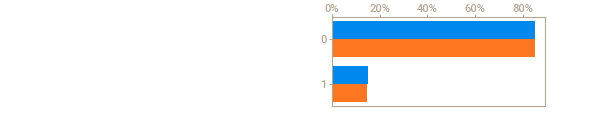
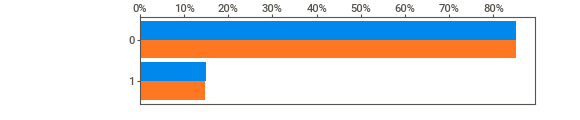
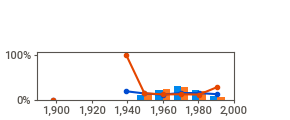
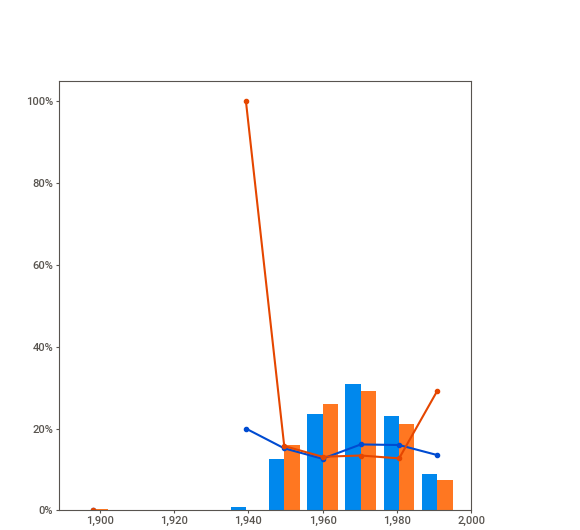
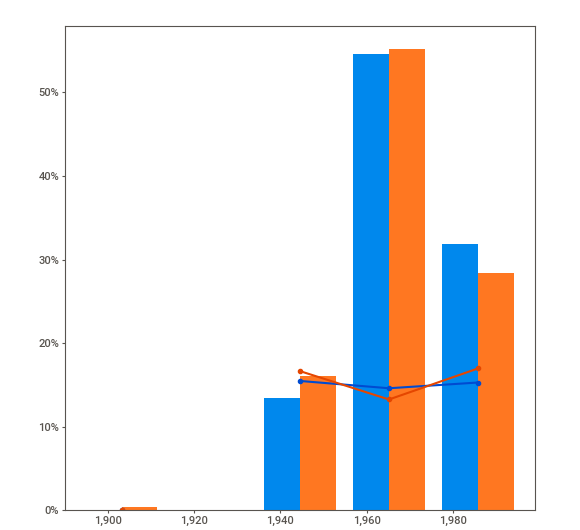
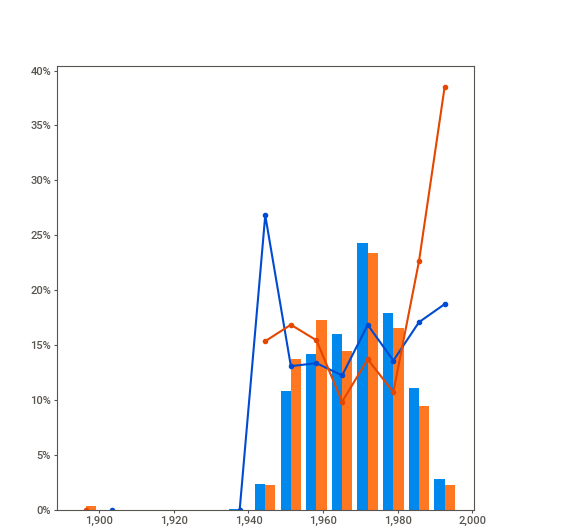
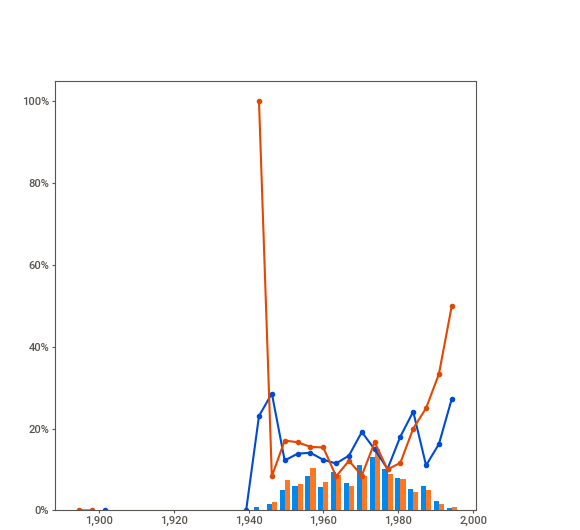
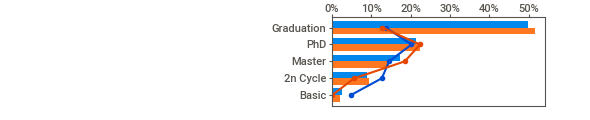
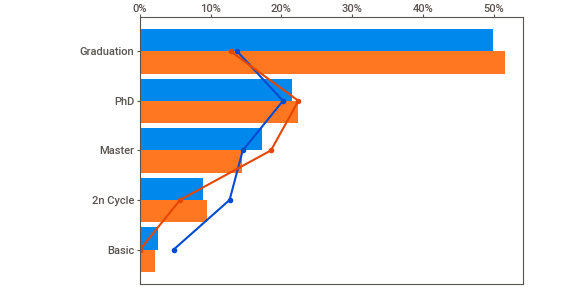
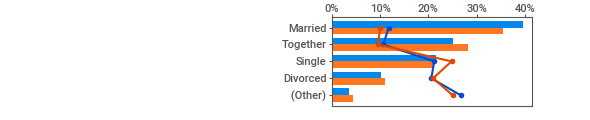
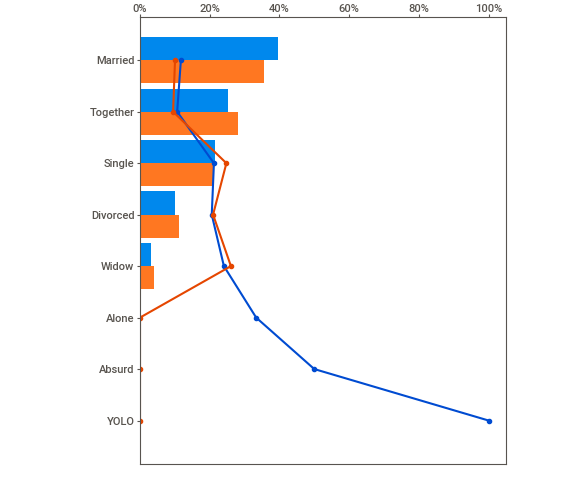
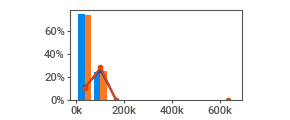
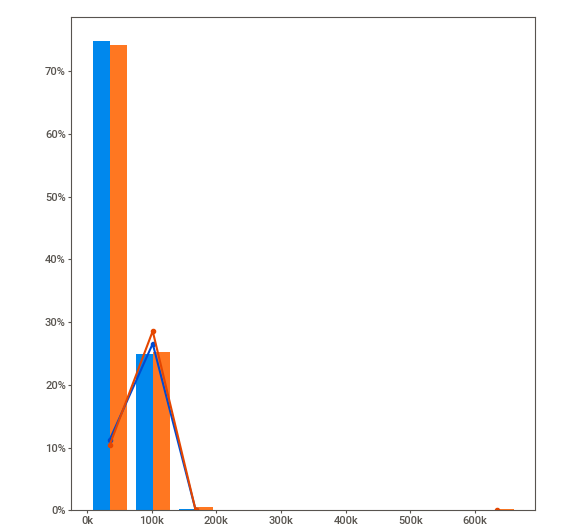
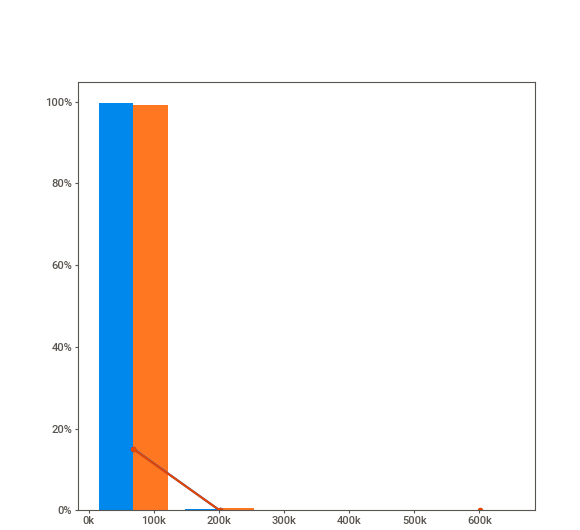
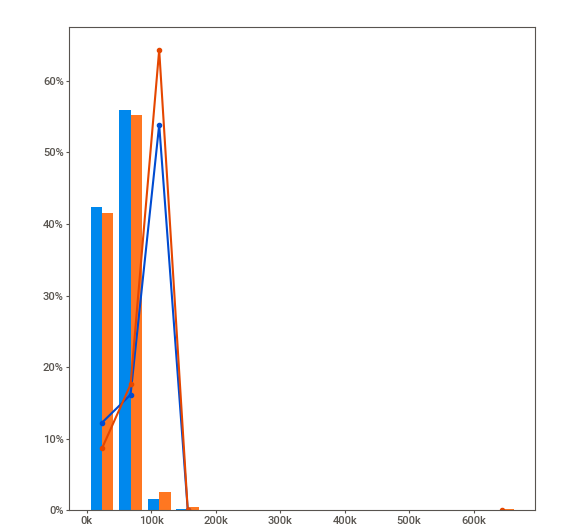
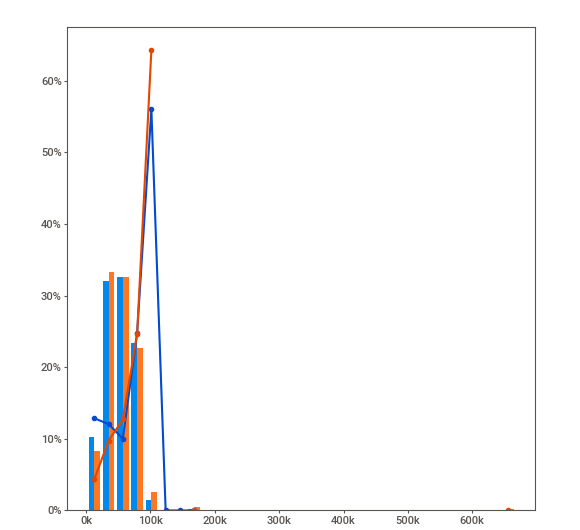
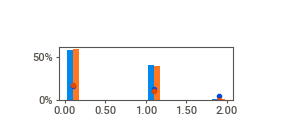
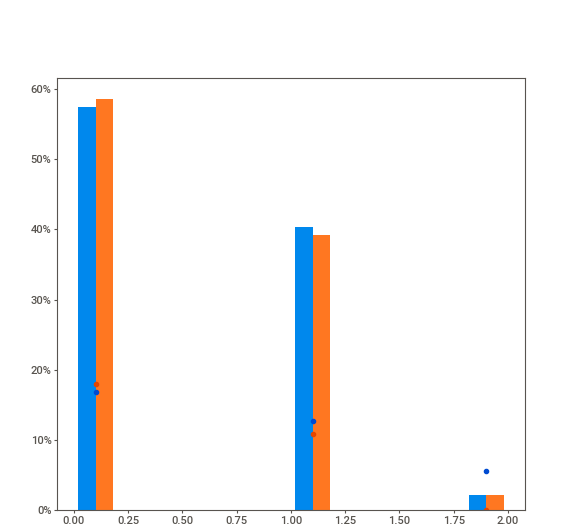
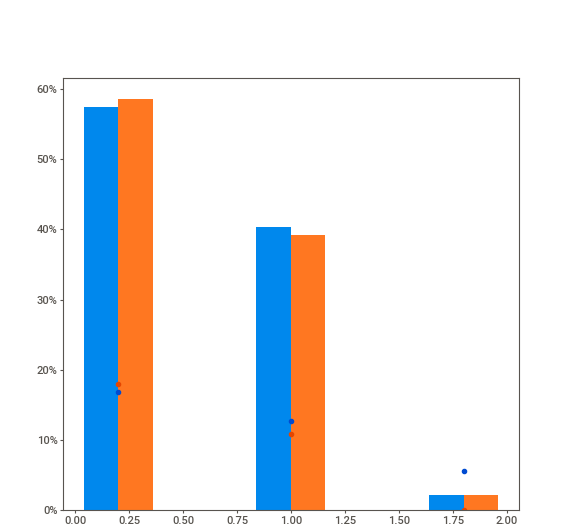
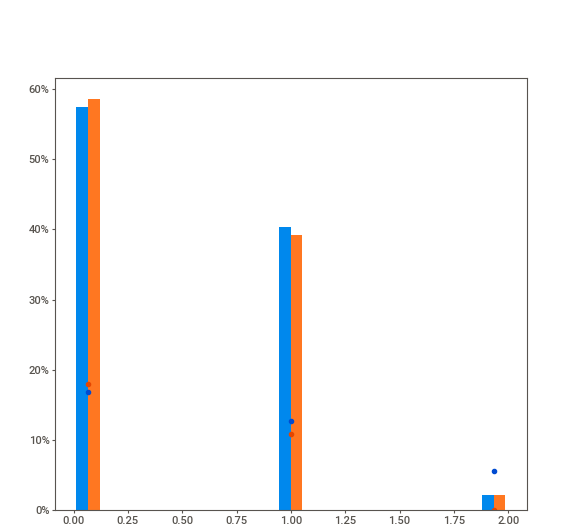
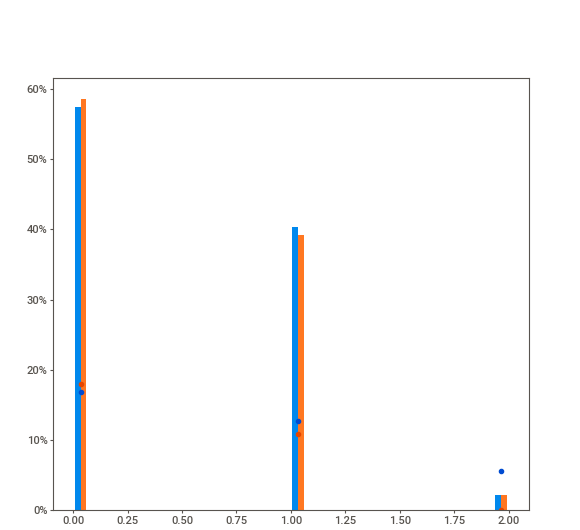
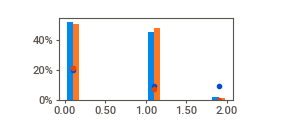
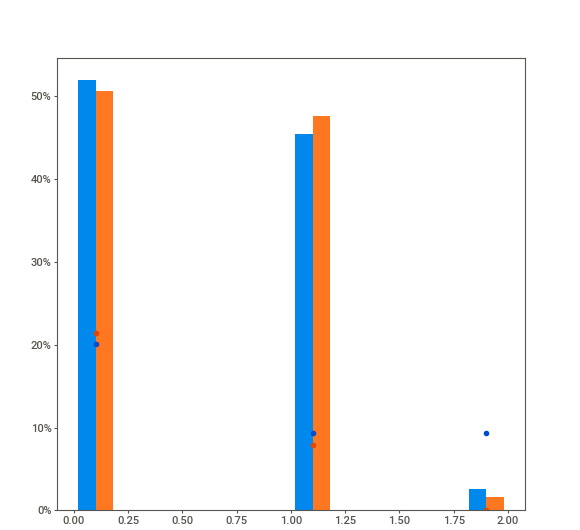
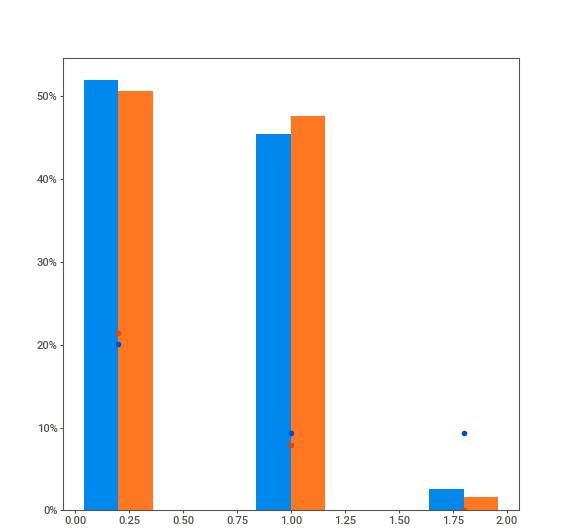
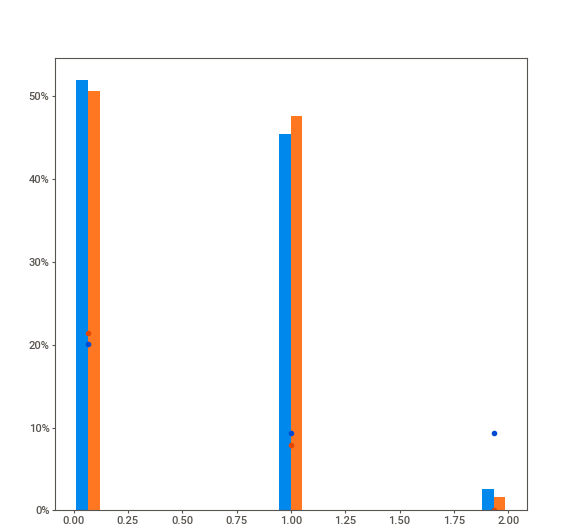
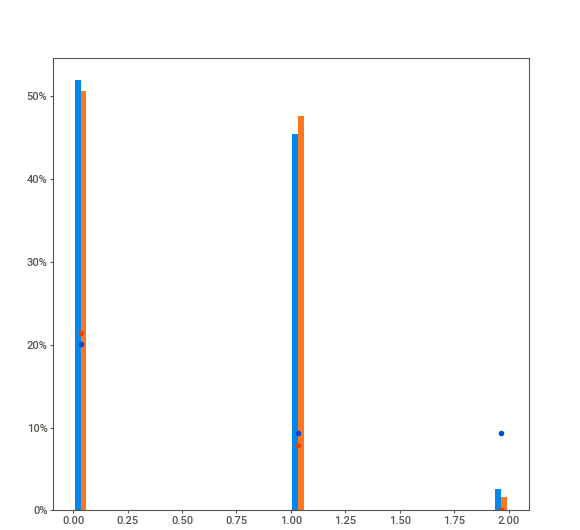
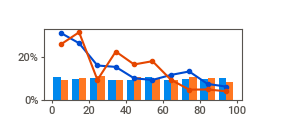
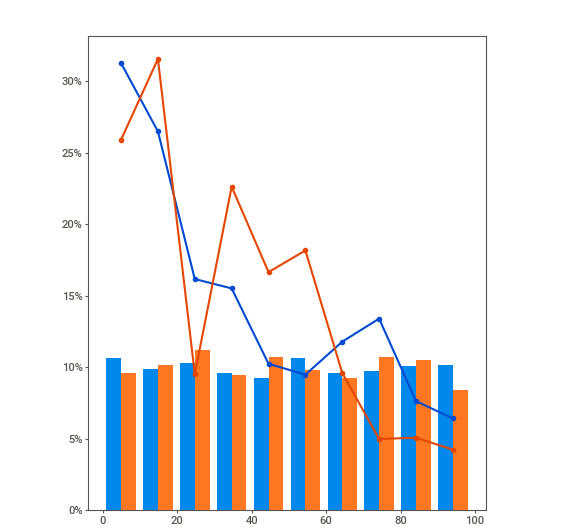
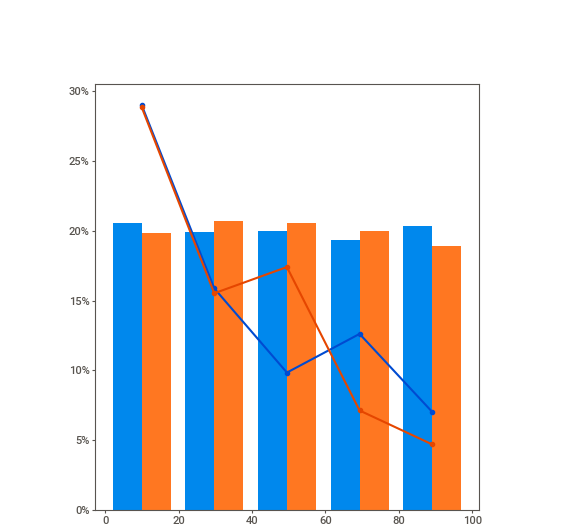
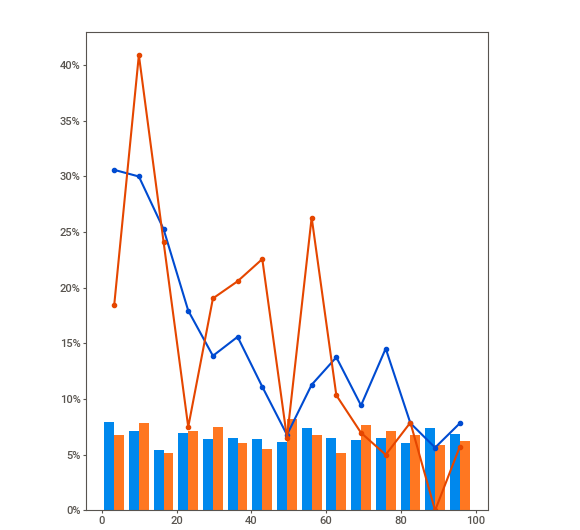
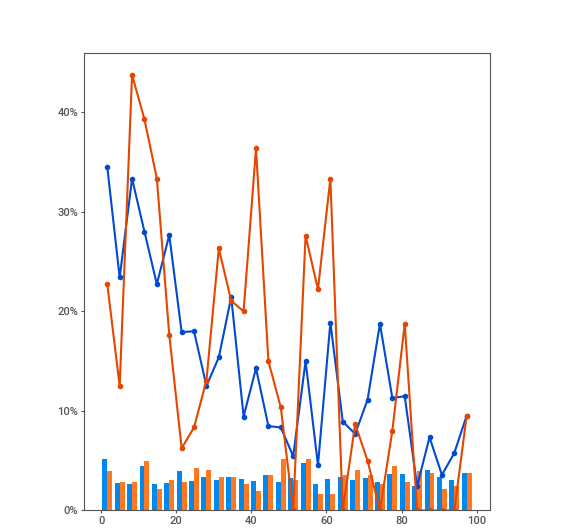
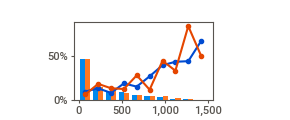
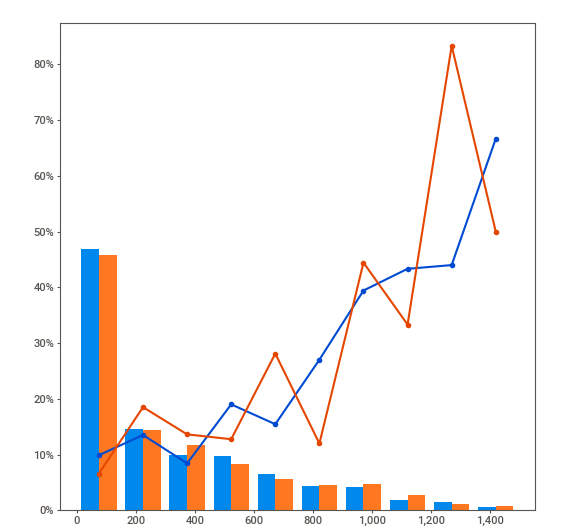
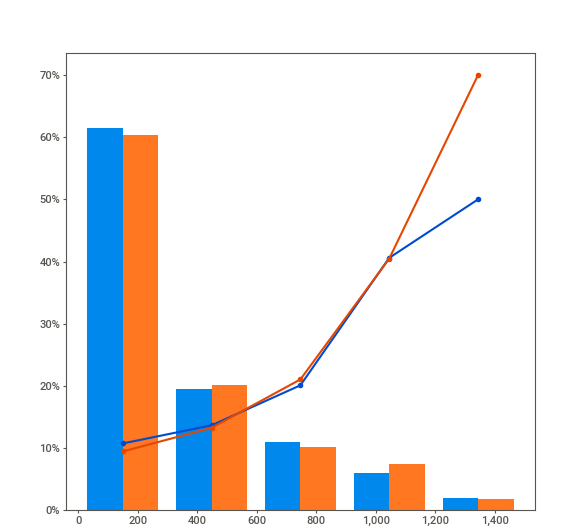
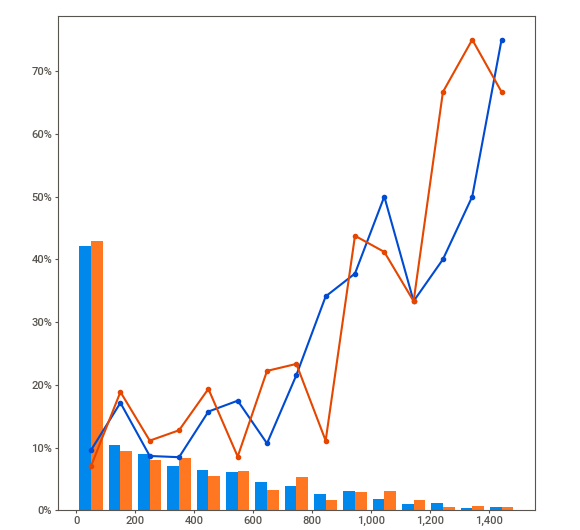
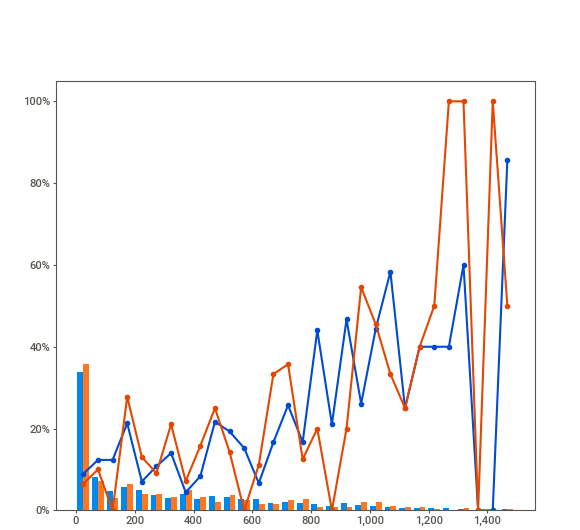
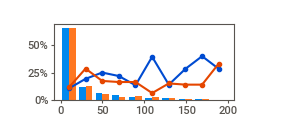
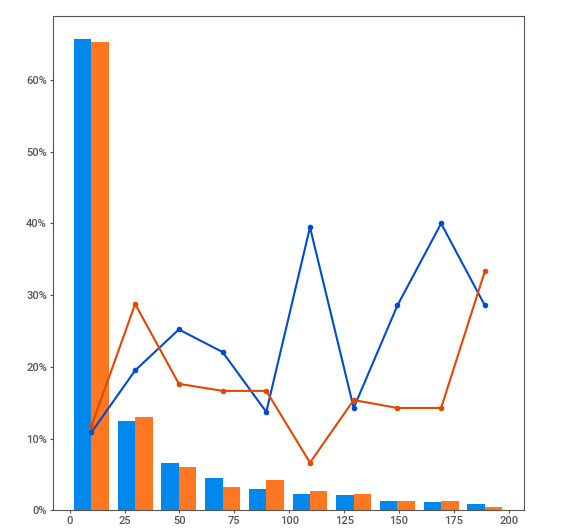
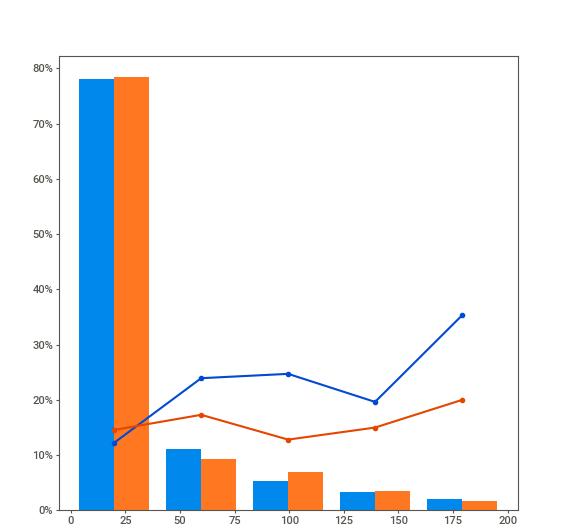
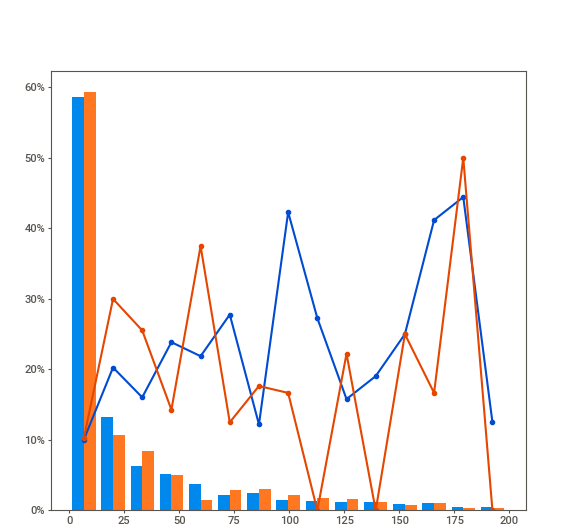
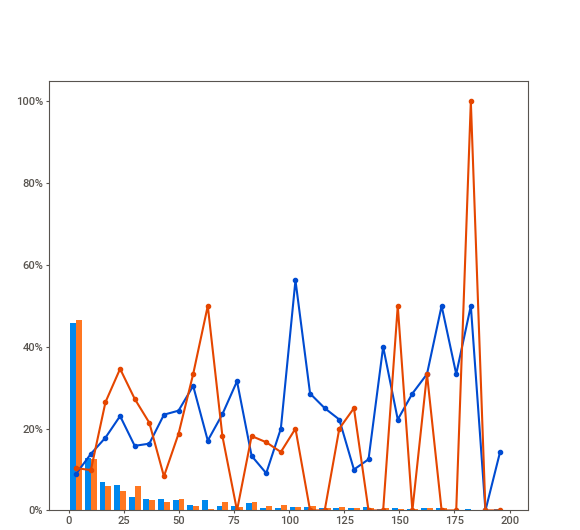
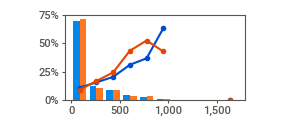
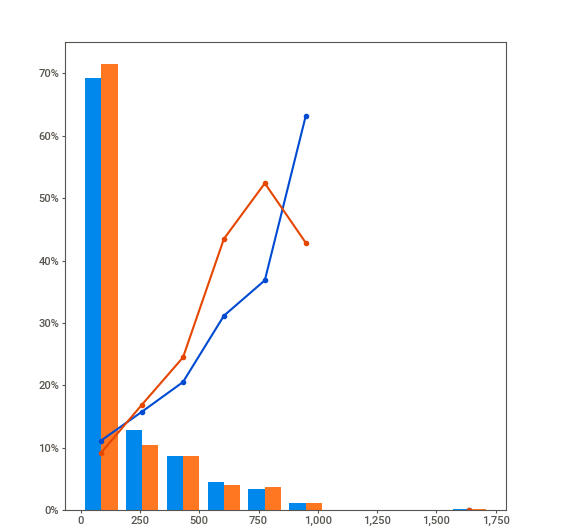
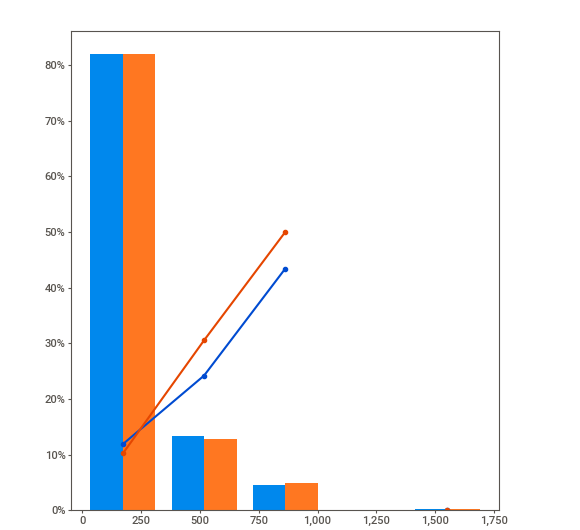
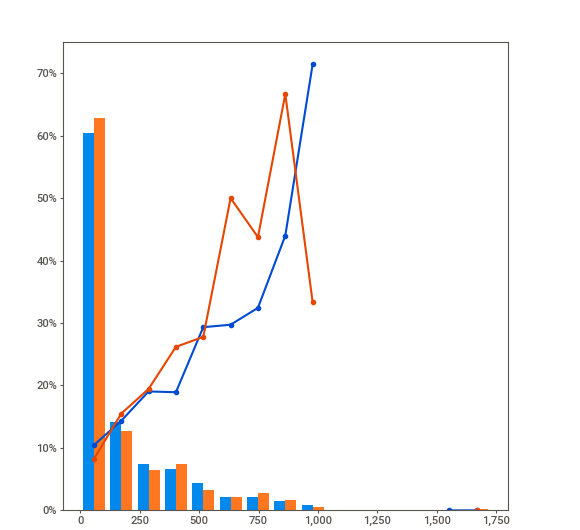
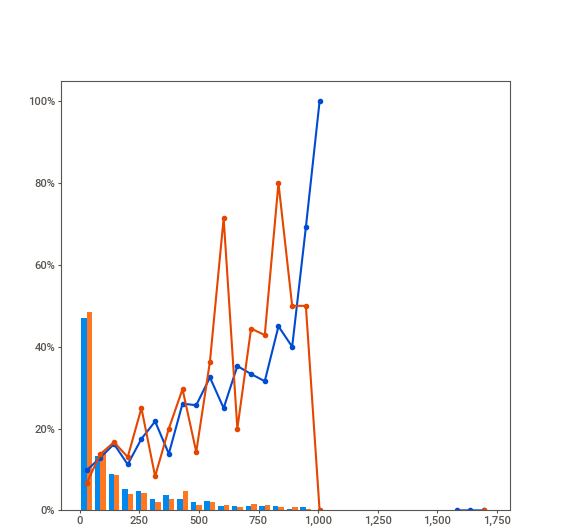
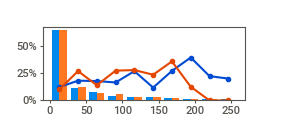
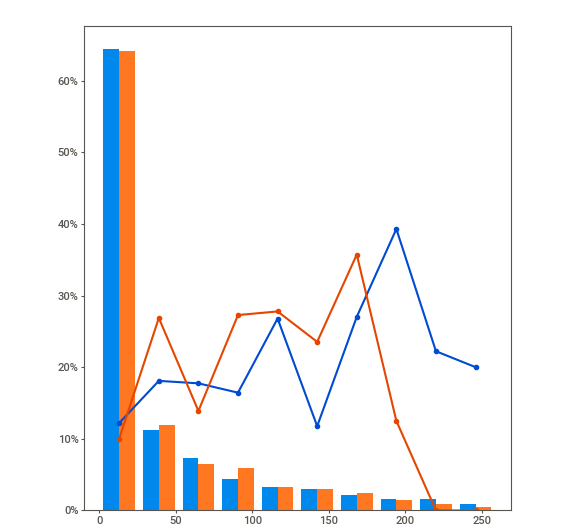
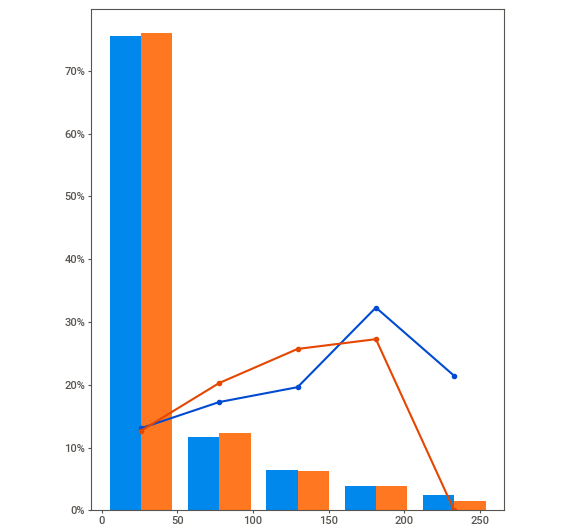
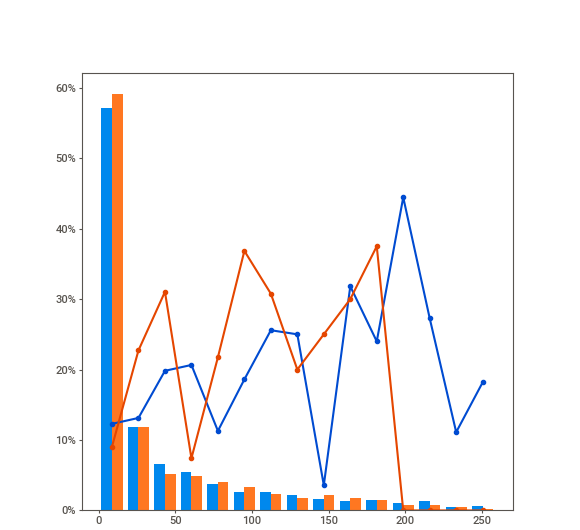
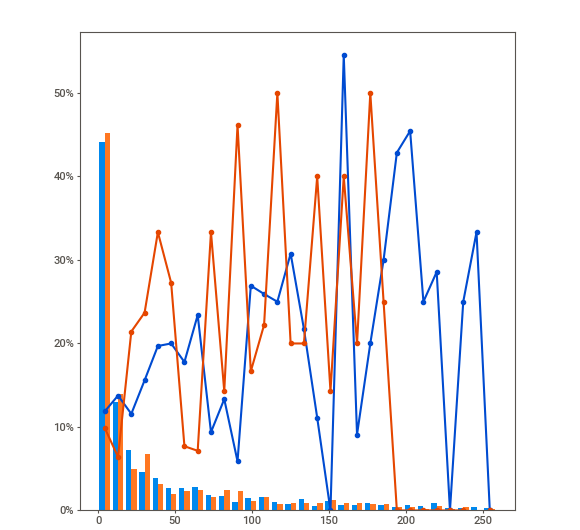
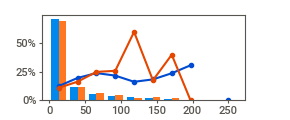
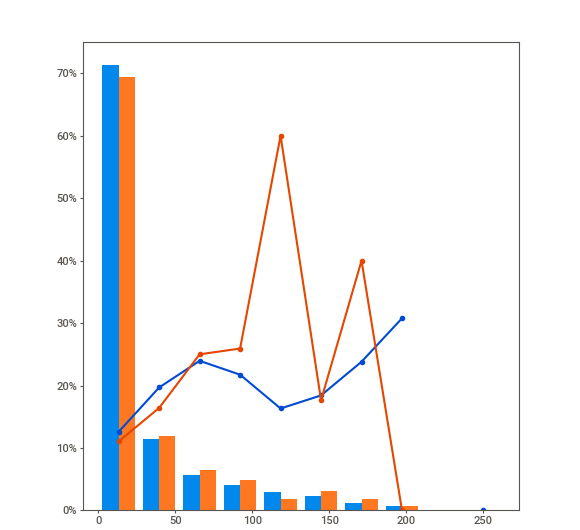
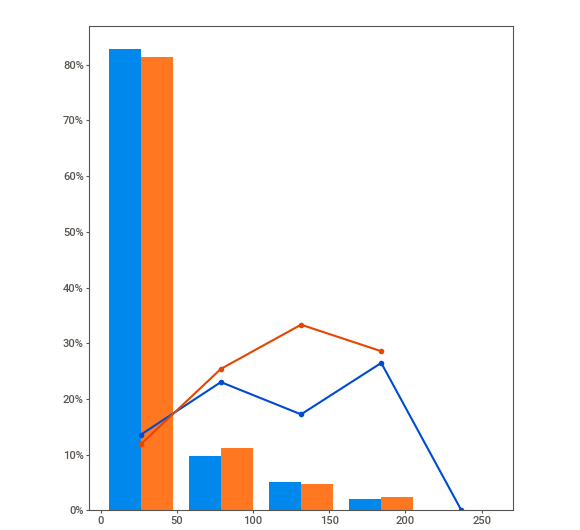
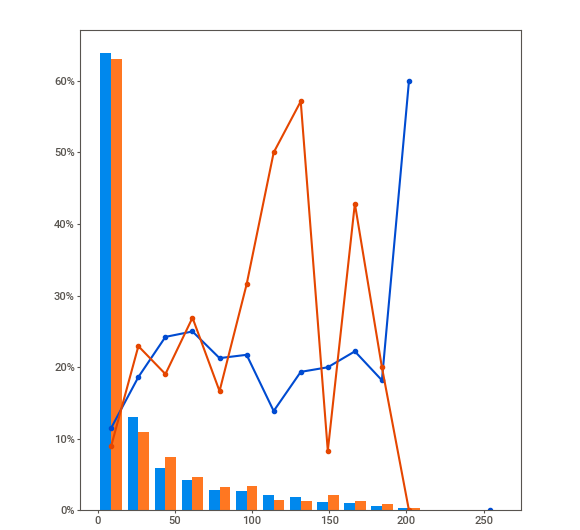
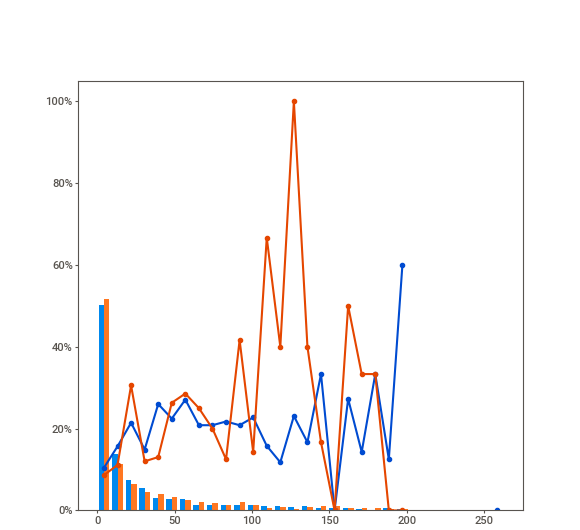
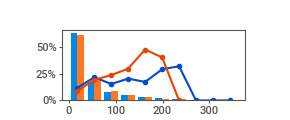
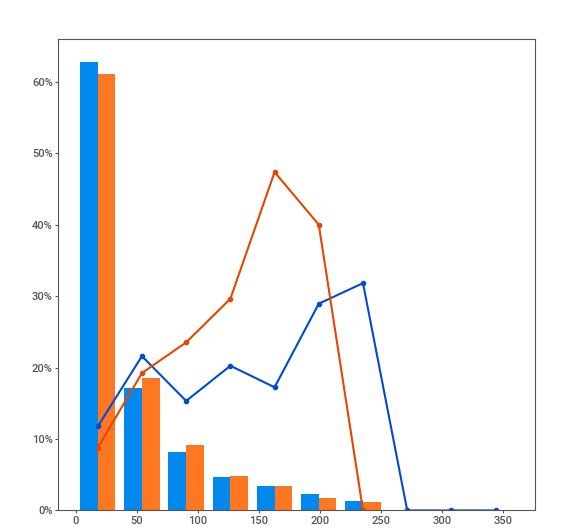
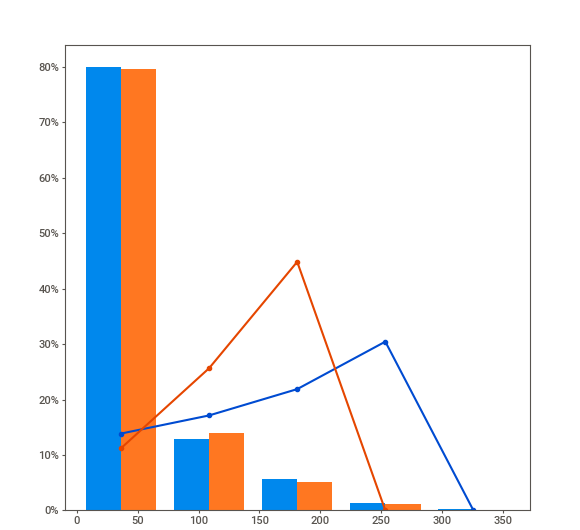
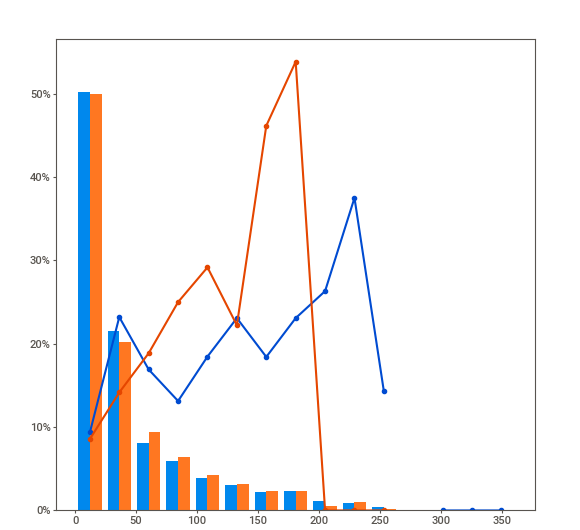
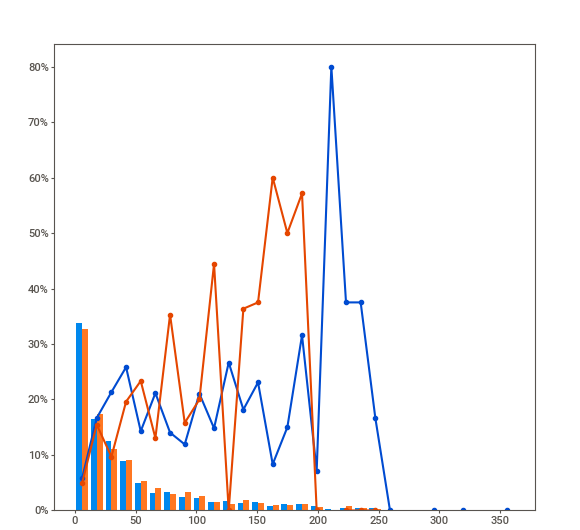
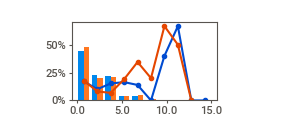
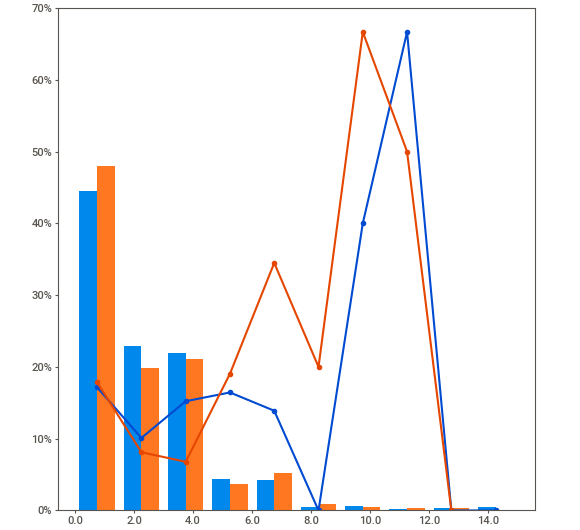
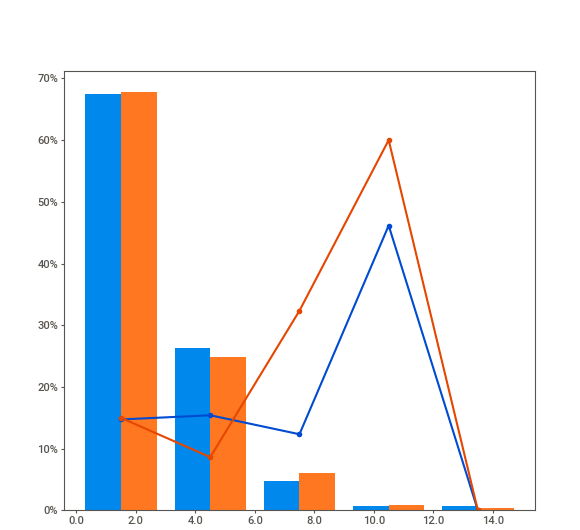
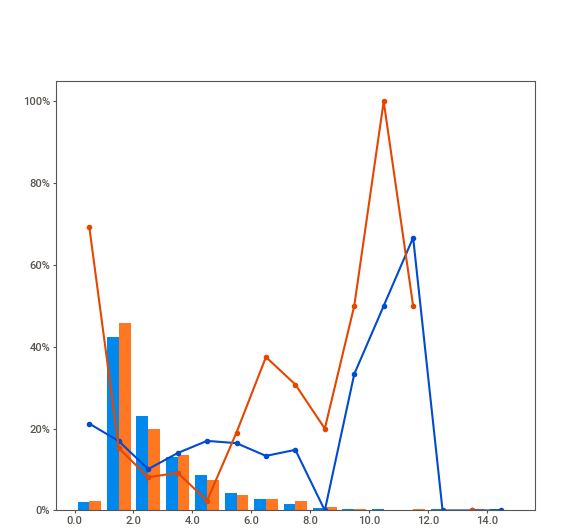
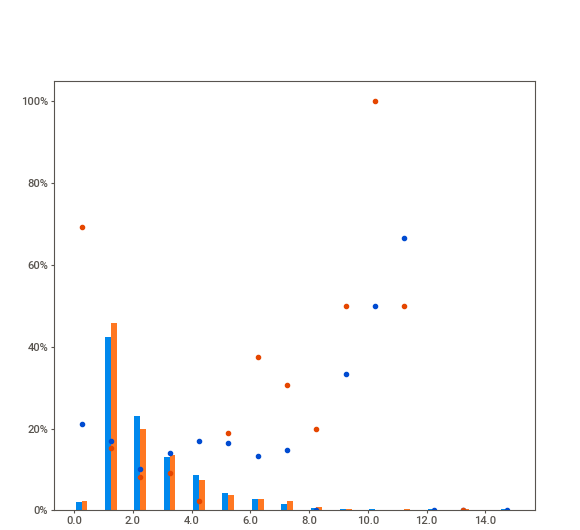
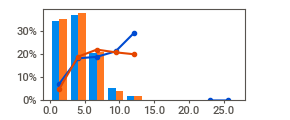
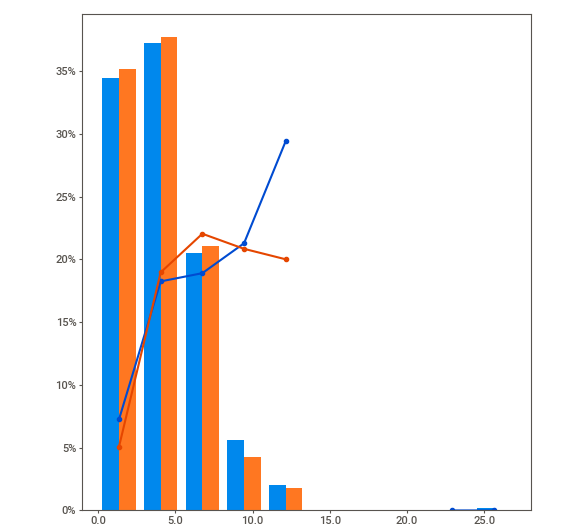
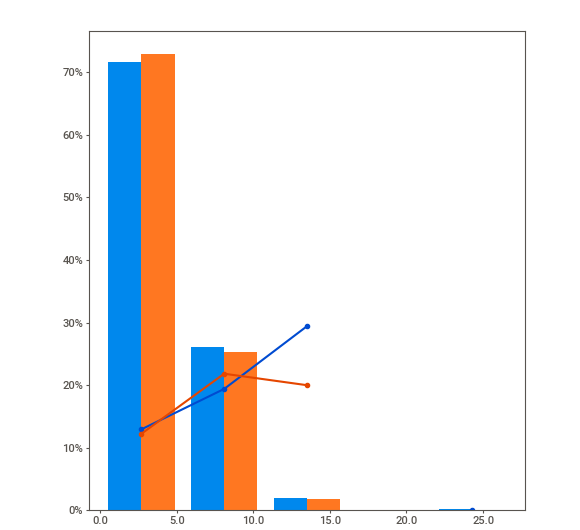
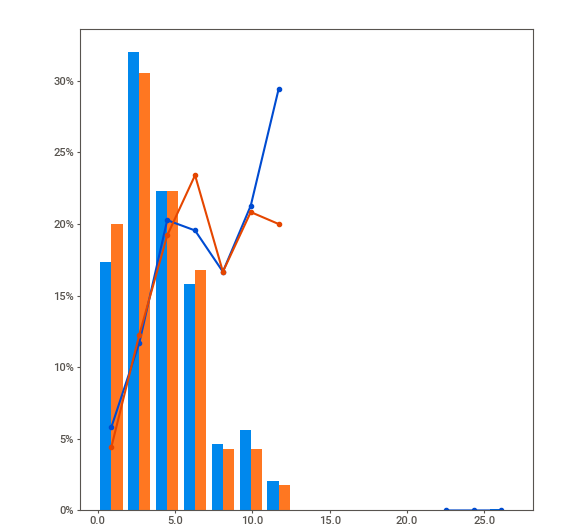
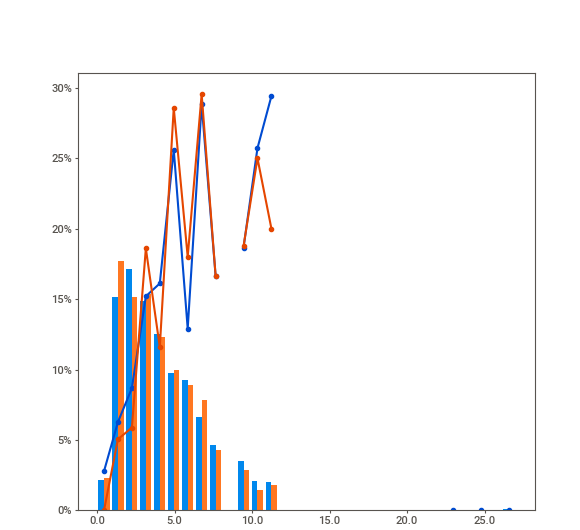
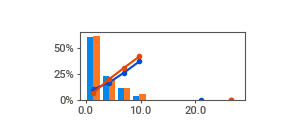
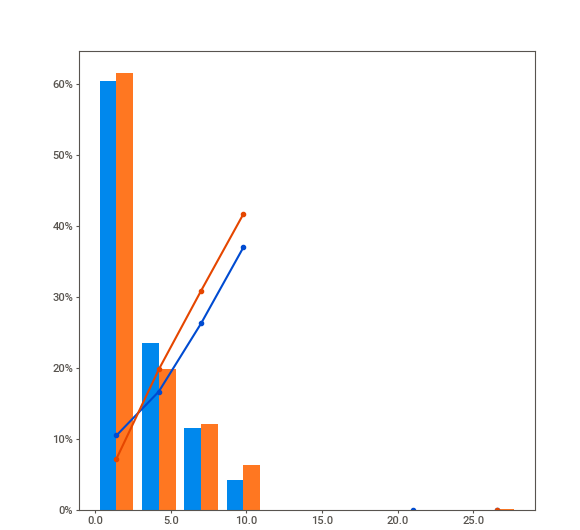
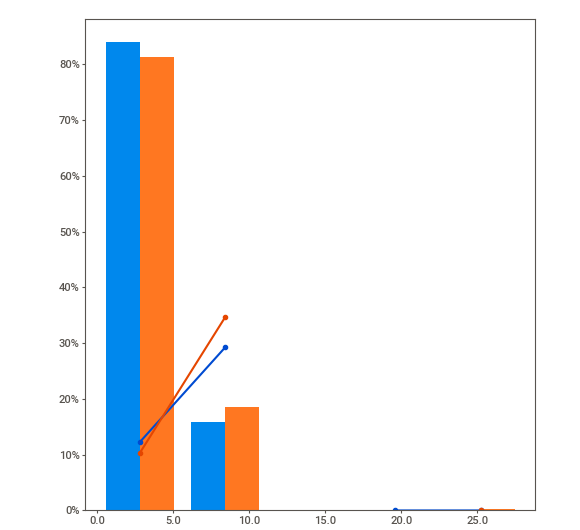
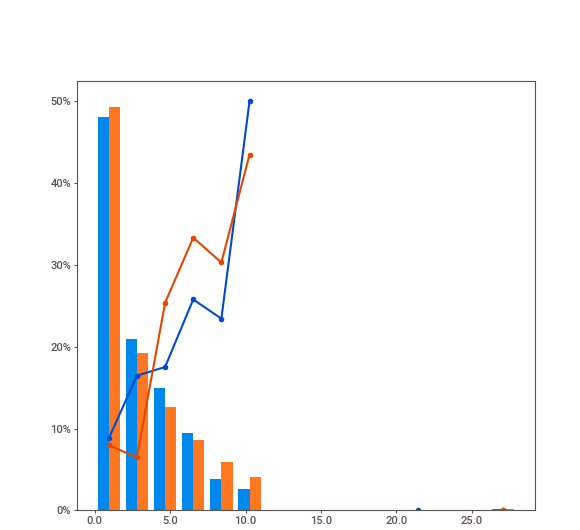
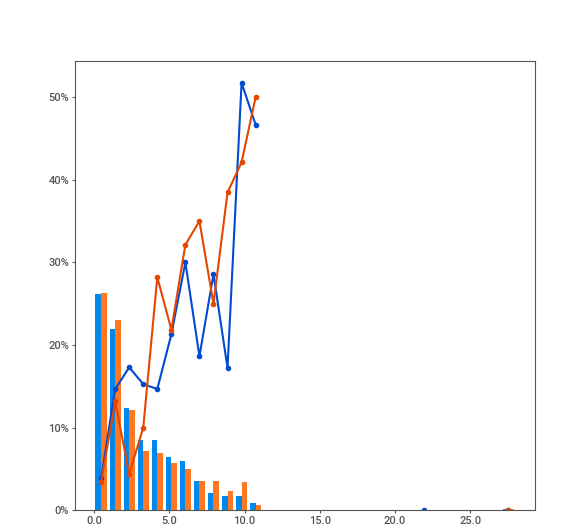
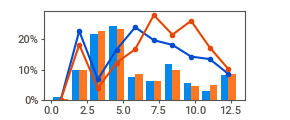
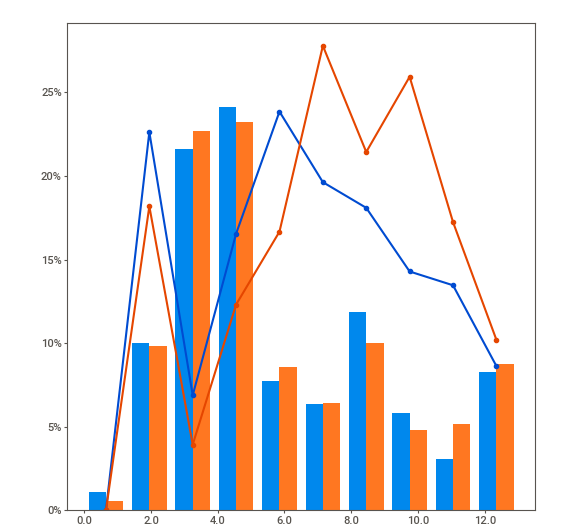
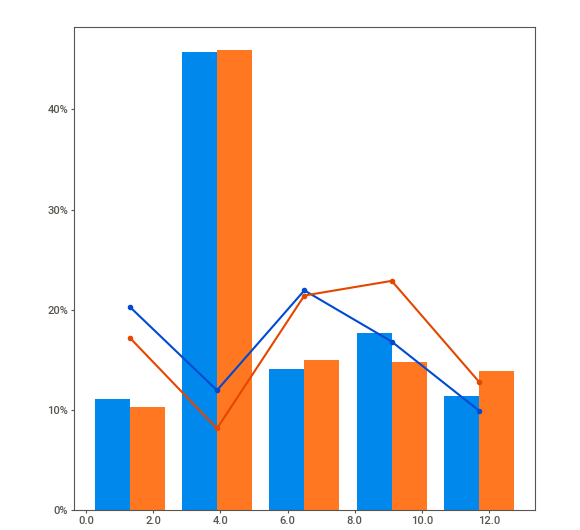
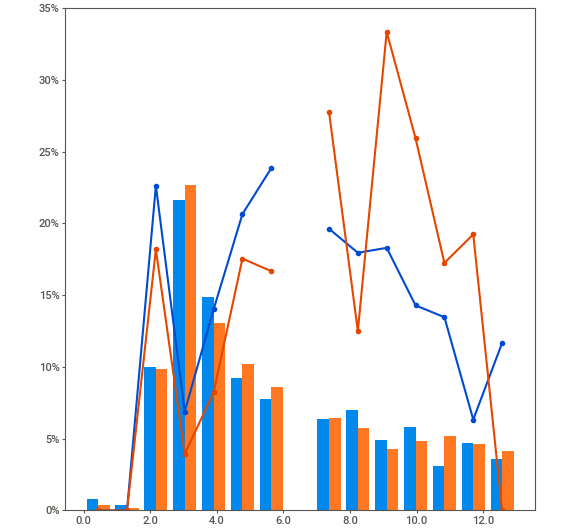
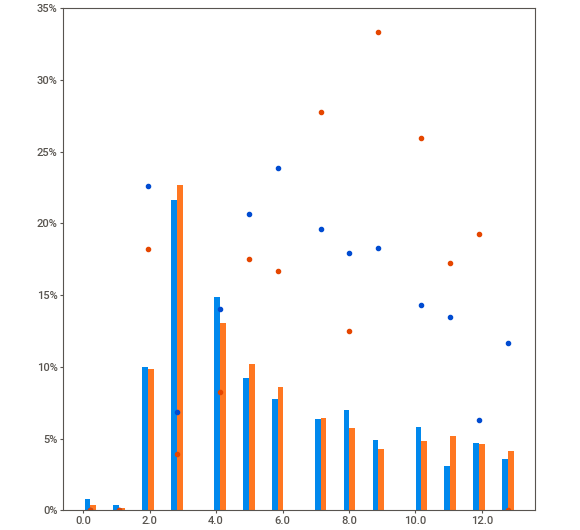
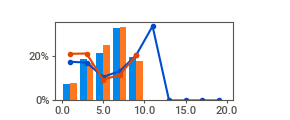
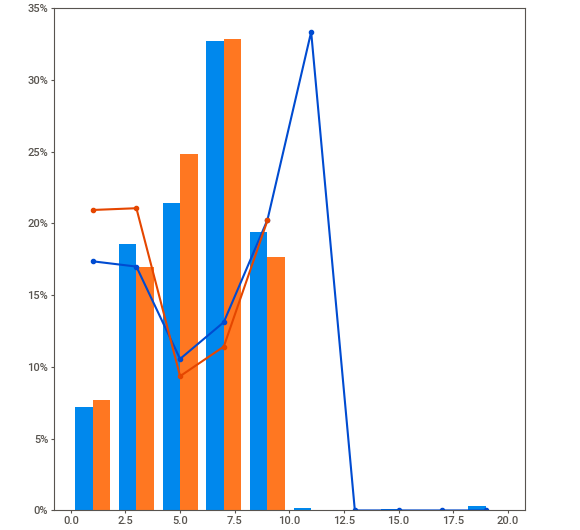
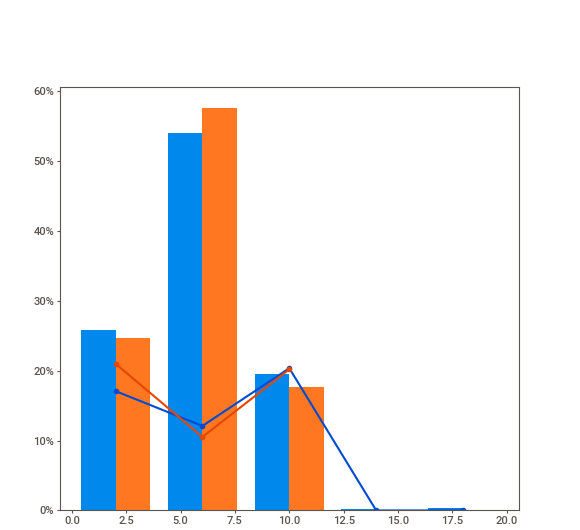
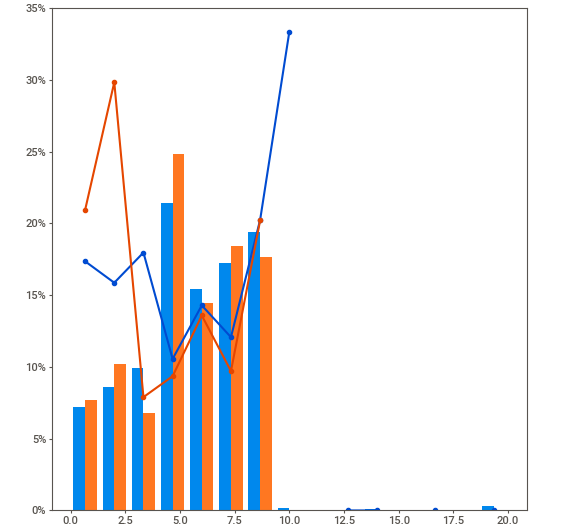
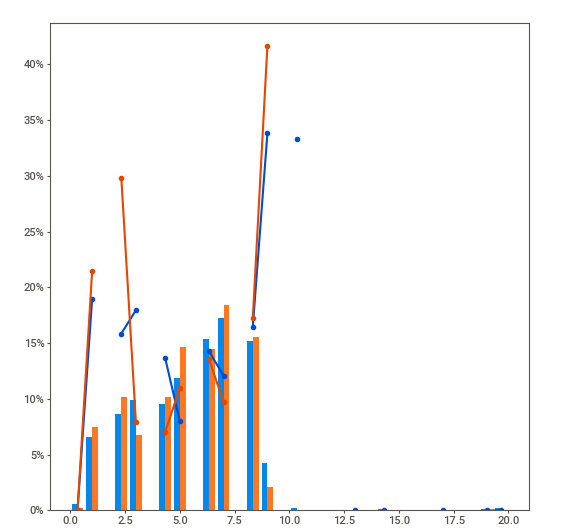
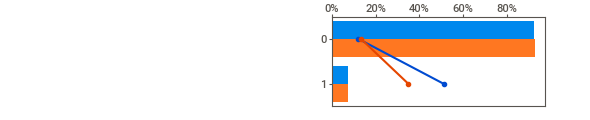
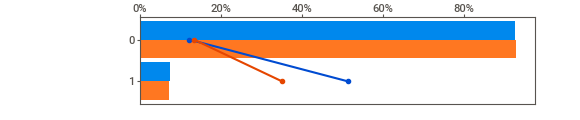
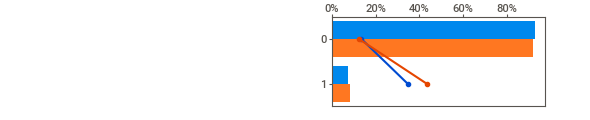
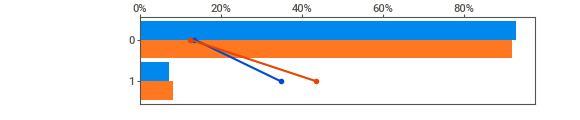
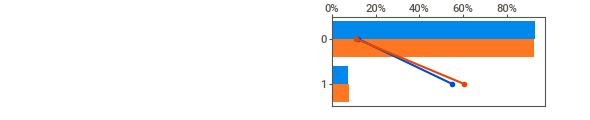
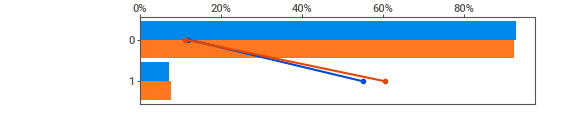
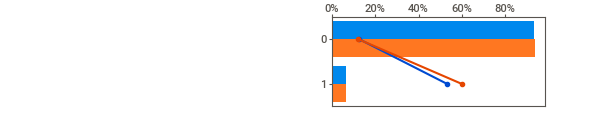
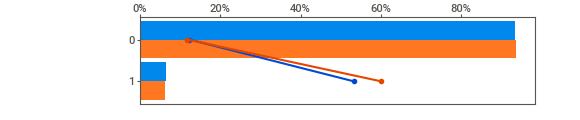
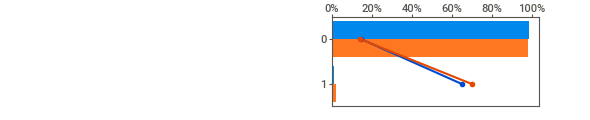
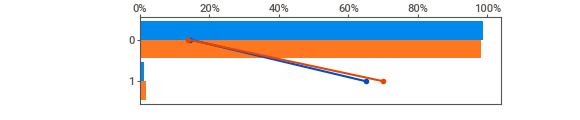
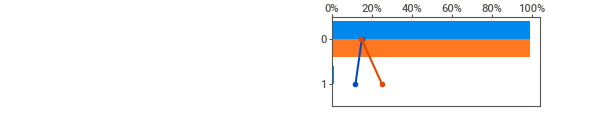
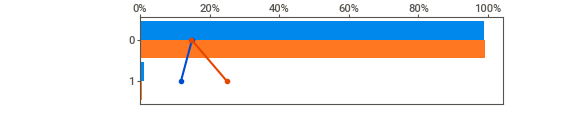
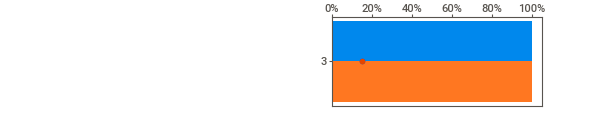
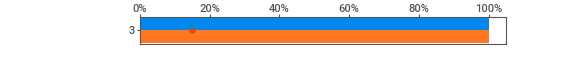
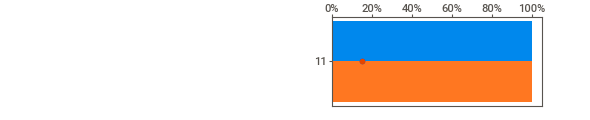
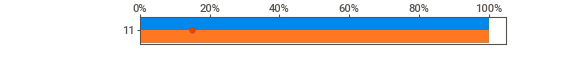
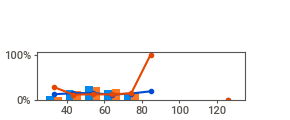
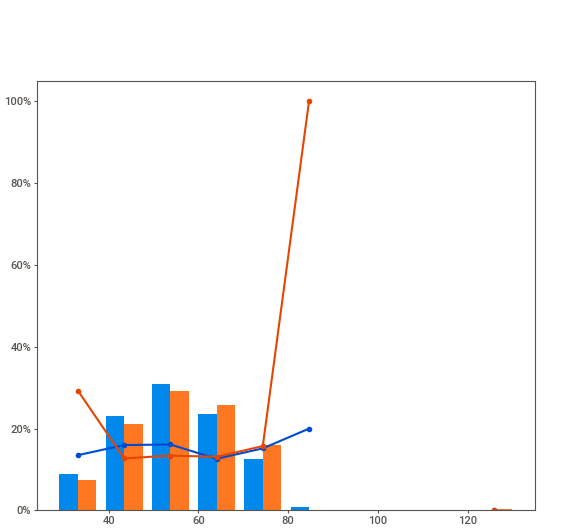
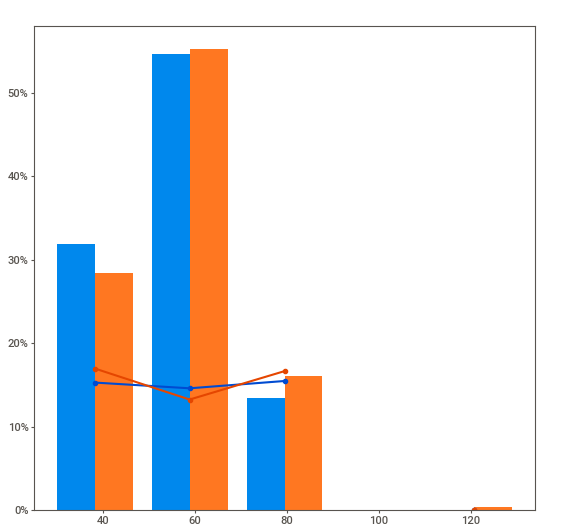
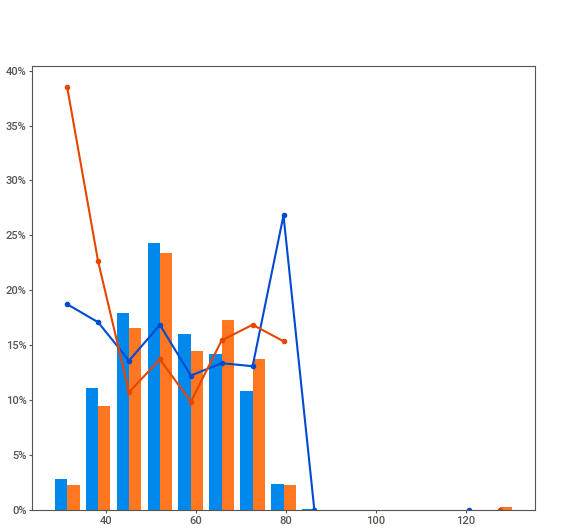
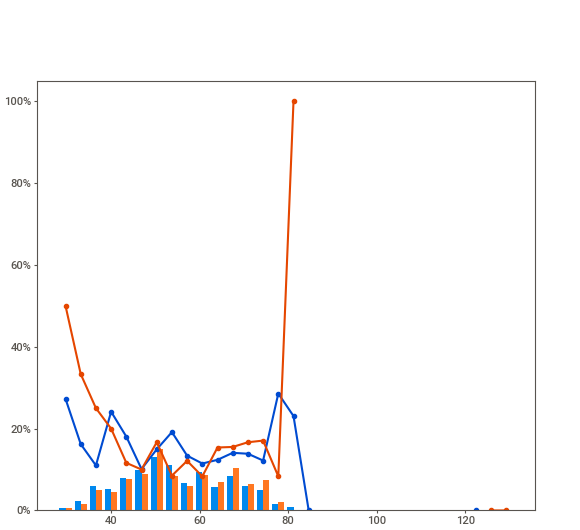
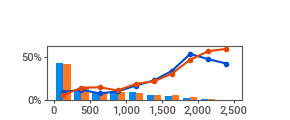
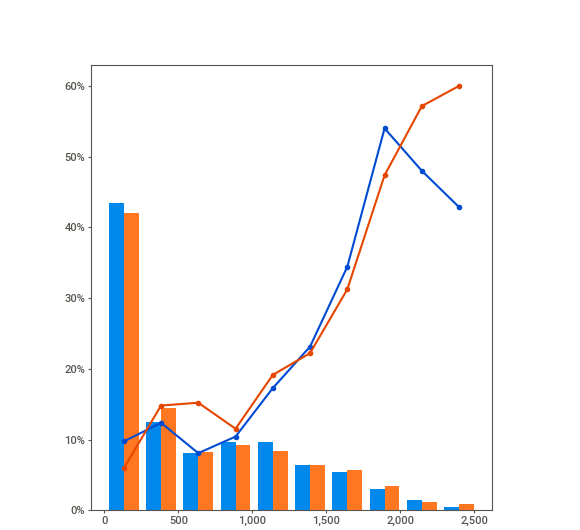
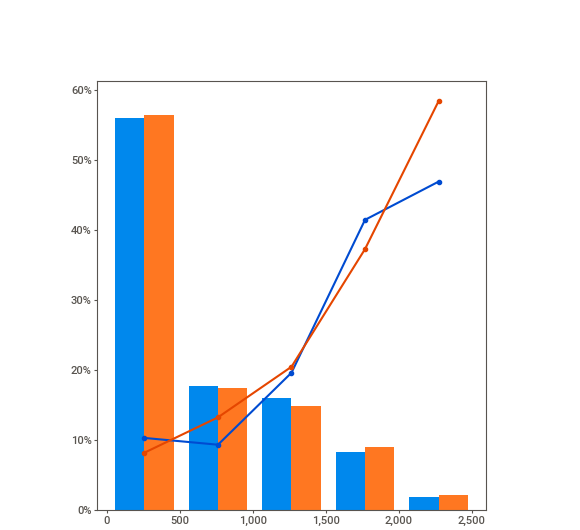
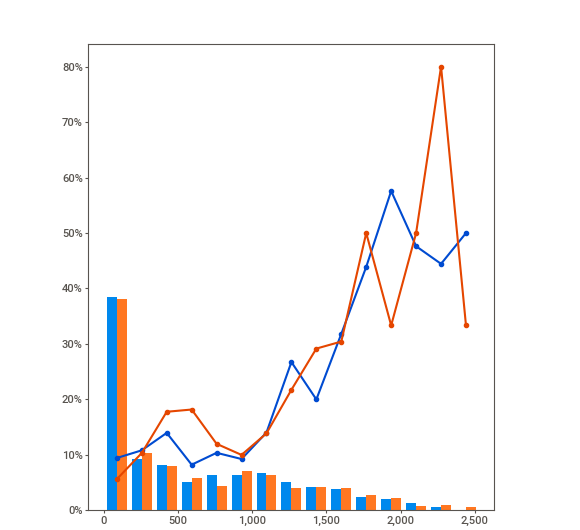
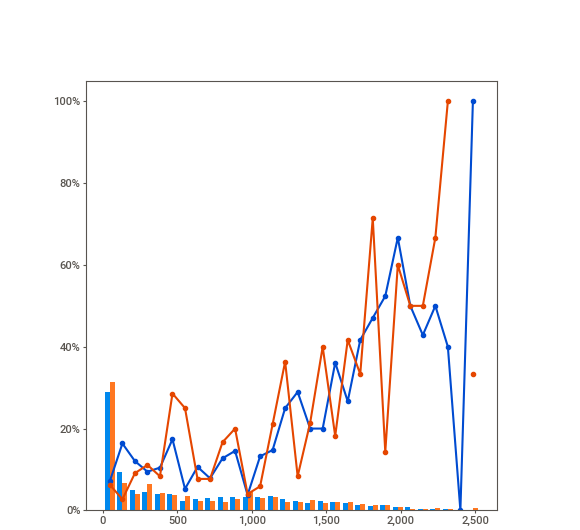
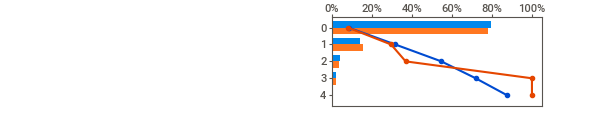
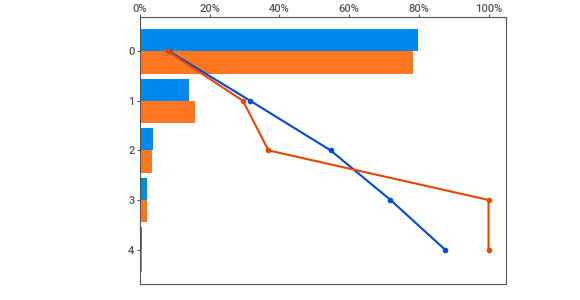
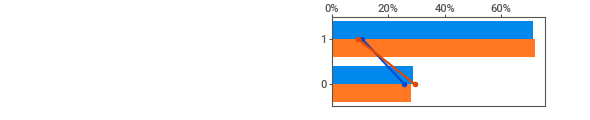
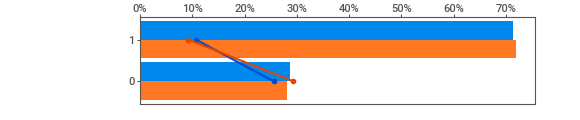
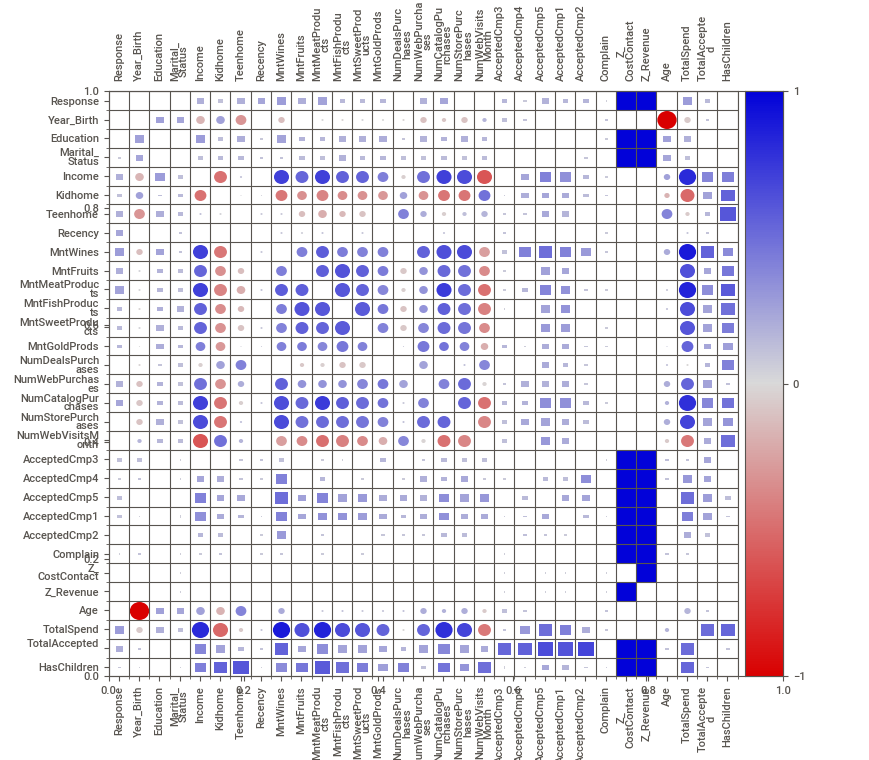
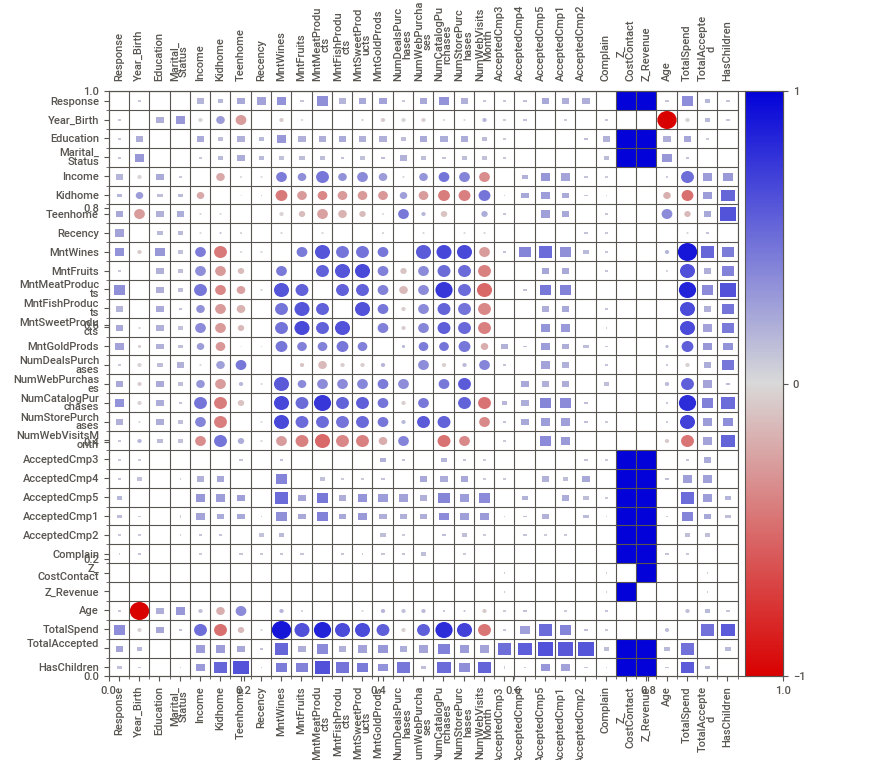

In [4]:


import sweetviz as sv
import pandas as pd
import numpy as np
import os, warnings
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
OUT = "output_sweetviz"
os.makedirs(OUT, exist_ok=True)

# ── 0. Nạp & Feature Engineering ────────────────────────
df = pd.read_csv("marketing_campaign.csv", sep=';')
df["Age"]          = 2024 - df["Year_Birth"]
sol_cols         = ["MntWines","MntFruits","MntMeatProducts",
                      "MntFishProducts","MntSweetProducts","MntGoldProds"]
df["TotalSpend"]   = df[sol_cols].sum(axis=1)
df["TotalAccepted"]= df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
                           "AcceptedCmp4","AcceptedCmp5"]].sum(axis=1)
df["HasChildren"]  = ((df["Kidhome"] + df["Teenhome"]) > 0).astype(int)

print("="*60)
print("  MARKETING CAMPAIGN – SWEETVIZ EDA")
print("="*60)
print(f"  Số dòng: {df.shape[0]:,}  |  Số cột: {df.shape[1]}")
print(f"  Missing: Income={df['Income'].isnull().sum()} dòng (1.96%)")

# ── FeatureConfig: skip cột dư; force_cat cho cột nhị phân ─
feature_cfg = sv.FeatureConfig(
    skip      = ["ID", "Dt_Customer"],
    force_num = ["Kidhome", "Teenhome"],
    force_cat = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3",
                 "AcceptedCmp4","AcceptedCmp5","Complain","HasChildren"]
    # Lưu ý: KHÔNG force_cat cho Response vì nó là target (bool/num)
)

# ══════════════════════════════════════════════════════════
# TÍNH NĂNG 1: sv.analyze() – Báo cáo EDA toàn bộ dataset
# ══════════════════════════════════════════════════════════
print("\n[1/5] sv.analyze() – EDA toàn bộ (target_feat='Response')")
report_full = sv.analyze(
    source            = df,
    target_feat       = "Response",   # phân tích ảnh hưởng tới biến mục tiêu
    feat_cfg          = feature_cfg,
    pairwise_analysis = "on"          # bật ma trận tương quan giữa các cặp biến
)
report_full.show_html(
    filepath     = os.path.join(OUT, "01_full_eda.html"),
    open_browser = False,
    layout       = "vertical",
    scale        = 0.9
)
print("   ✔ 01_full_eda.html  – Báo cáo EDA đầy đủ + ma trận tương quan")

# ══════════════════════════════════════════════════════════
# TÍNH NĂNG 2: sv.compare() – Train vs Test split
# ══════════════════════════════════════════════════════════
print("\n[2/5] sv.compare() – Phân phối Train (75%) vs Test (25%)")
train_df, test_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df["Response"]
)
report_cmp = sv.compare(
    source      = [train_df, "Train Set (75%)"],
    compare     = [test_df,  "Test Set (25%)"],
    target_feat = "Response",
    feat_cfg    = feature_cfg
)
report_cmp.show_html(
    filepath     = os.path.join(OUT, "02_train_vs_test.html"),
    open_browser = False
)
print("   ✔ 02_train_vs_test.html – Kiểm tra data leakage & phân phối")

# ══════════════════════════════════════════════════════════
# TÍNH NĂNG 3a: sv.compare_intra() – So sánh theo Education
# ══════════════════════════════════════════════════════════
print("\n[3/5] sv.compare_intra() – PhD/Master vs Bằng khác")
report_edu = sv.compare_intra(
    source_df        = df,
    condition_series = df["Education"].isin(["PhD", "Master"]),
    names            = ["PhD / Master", "Trình độ khác"],
    target_feat      = "TotalSpend",
    feat_cfg         = feature_cfg
)
report_edu.show_html(
    filepath      = os.path.join(OUT, "03_intra_education.html"),
    open_browser = False
)
print("   ✔ 03_intra_education.html – Hành vi tiêu dùng theo học vấn")

# ─── 3b: compare_intra theo phản hồi chiến dịch ──────────
print("\n[4/5] sv.compare_intra() – Phản hồi vs Không phản hồi CMP")
report_resp = sv.compare_intra(
    source_df        = df,
    condition_series = (df["Response"] == 1),
    names            = ["Phản hồi Campaign", "Không phản hồi"],
    target_feat      = "TotalSpend",
    feat_cfg         = feature_cfg
)
report_resp.show_html(
    filepath     = os.path.join(OUT, "04_intra_response.html"),
    open_browser = False
)
print("   ✔ 04_intra_response.html – Profiling khách hàng chuyển đổi")

# ══════════════════════════════════════════════════════════
# TÍNH NĂNG 4: Truy xuất thống kê qua _features (API nội bộ)
# ══════════════════════════════════════════════════════════
print("\n[5/5] _features API – Trích xuất thống kê số vào DataFrame")
feats_dict = report_full._features
num_feats  = ["Income","TotalSpend","Age","Recency",
              "NumWebPurchases","NumStorePurchases","MntWines","MntMeatProducts"]
rows = []
for feat in num_feats:
    if feat not in feats_dict:
        continue
    fd = feats_dict[feat]
    st = fd.get("stats", {})
    bs = fd.get("base_stats", {})

    def safe_float(d, k, dec=1):
        v = d.get(k)
        if v is None:
            return "N/A"
        try:
            return round(float(str(v).split()[0].replace(",","")), dec)
        except:
            return "N/A"

    rows.append({
        "Feature"   : feat,
        "N_Missing" : safe_float(bs, "num_missing", 0),
        "Mean"      : round(float(st["mean"]),1)    if "mean"      in st else "N/A",
        "Std"       : round(float(st["std"]),1)     if "std"       in st else "N/A",
        "Min"       : round(float(st["min"]),1)     if "min"       in st else "N/A",
        "Q1"        : round(float(st["perc25"]),1)  if "perc25"    in st else "N/A",
        "Median"    : round(float(st["perc50"]),1)  if "perc50"    in st else "N/A",
        "Q3"        : round(float(st["perc75"]),1)  if "perc75"    in st else "N/A",
        "Max"       : round(float(st["max"]),1)     if "max"       in st else "N/A",
        "Skew"      : round(float(st["skewness"]),3)if "skewness"  in st else "N/A",
    })

summary_df = pd.DataFrame(rows)
print()
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUT, "sweetviz_feature_stats.csv"), index=False)
print("\n   ✔ sweetviz_feature_stats.csv – Thống kê có thể dùng trong code")

# ─── Thống kê tổng quát dataset ───────────────────────────
ss = report_full.summary_source
print("\n── Dataset-level Summary ────────────────────────────")
print(f"  Tên      : {ss['name']}")
print(f"  Hàng     : {ss['num_rows']:,}")
print(f"  Cột p/tích: {ss['num_columns']}")
print(f"  Numeric  : {ss['num_numerical']}")
print(f"  Categorical: {ss['num_cat']}")
print(f"  Text     : {ss['num_text']}")
print(f"  Bộ nhớ  : {int(ss['memory_total'])//1024} KB")

# ─── Kết quả ──────────────────────────────────────────────
print("\n" + "="*60)
print("  KẾT QUẢ – File lưu tại:", OUT)
print("="*60)
for f in sorted(os.listdir(OUT)):
    sz = os.path.getsize(os.path.join(OUT, f))
    tag = "HTML" if f.endswith(".html") else "CSV "
    print(f"  [{tag}] {f:<42} {sz//1024:>5} KB")
print("="*60)


# ══════════════════════════════════════════════════════════
# HIỂN THỊ HTML TRỰC TIẾP LÊN MÀN HÌNH COLAB
# ══════════════════════════════════════════════════════════
print("\n=> ĐANG HIỂN THỊ CÁC BÁO CÁO HTML TRỰC TIẾP TRONG NOTEBOOK...")

display(HTML("<h3>1. Báo cáo EDA Toàn bộ Dataset</h3>"))
report_full.show_notebook(w="100%", h="700", scale=0.9, layout="vertical")

display(HTML("<h3>2. Báo cáo So sánh: Train vs Test</h3>"))
report_cmp.show_notebook(w="100%", h="700", scale=0.9, layout="vertical")

# Lưu ý: Mình tạm thời ẩn hai báo cáo compare_intra phía dưới để tránh việc trình duyệt bị quá tải
# (vì mỗi báo cáo HTML của Sweetviz tiêu tốn khá nhiều RAM của tab trình duyệt).
# Nếu bạn cần xem trực tiếp chúng, chỉ cần xóa dấu `#` ở các dòng dưới đây.

# display(HTML("<h3>3. Báo cáo So sánh: PhD/Master vs Bằng khác</h3>"))
# report_edu.show_notebook(w="100%", h="700", scale=0.9, layout="vertical")

# display(HTML("<h3>4. Báo cáo So sánh: Phản hồi vs Không phản hồi CMP</h3>"))
# report_resp.show_notebook(w="100%", h="700", scale=0.9, layout="vertical")